## Implementación y análisis de YOLOv8 (AABB)

Detección de lomos de libros con *YOLOv8* detección AABB (*Ultralytics*) sobre *Book Spine 2*. Este notebook es el **brazo A** del experimento: mismo protocolo de evaluación que *Test Faster R-CNN.ipynb* (brazo B), para armar la tabla comparativa sin mezclar formatos de caja.

No usa OBB ni segmentación. No convierte a COCO: trabaja con *dataset/data.yaml* nativo.

Estructura alineada a *concepto/guía-de-comparación.md*. Las celdas de código se agregan después, una por sección.

## Setup — instalación de librerías

Instala en el kernel las dependencias de YOLOv8 (*ultralytics*, *torch* si hace falta, *numpy*, *Pillow*, *matplotlib*, *opencv*, *PyYAML*, *tqdm*, *pandas*, *roboflow*).

No lee *dataset/*, no entrena ni evalúa. En Colab conviene no reinstalar *torch* si ya trae GPU.

In [1]:
%pip install -q numpy
%pip install -q Pillow
%pip install -q matplotlib
%pip install -q opencv-python-headless
%pip install -q PyYAML
%pip install -q tqdm
%pip install -q pandas
%pip install -q roboflow
%pip install -q torch
%pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 kB 28.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 139.9 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.4/58.4 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 80.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 8.7 MB/s eta 0:00:00


## 2. Dataset Book Spine 2

Deja el export **YOLOv8** (detección AABB, no OBB) de *Book Spine 2* en *dataset/*, el mismo destino que Faster R-CNN.

Si ya hay *data.yaml* e imágenes, no descarga. La API key solo por entorno / *.env* / secret de Colab.

In [2]:
import os
from getpass import getpass
from pathlib import Path

from roboflow import Roboflow

ESPACIO_ROBOFLOW = "bookspine-fxfsx"
PROYECTO_ROBOFLOW = "book_spine_2"
FORMATO_EXPORTACION = "yolov8"  # AABB detección — no yolov8-obb
PATRONES_IMAGEN = ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.tif", "*.tiff", "*.webp")


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def cargar_variables_entorno(ruta: Path) -> None:
    if not ruta.is_file():
        return
    for linea in ruta.read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea.startswith("#") or "=" not in linea:
            continue
        clave, _, valor = linea.partition("=")
        os.environ.setdefault(clave.strip(), valor.strip().strip("'").strip('"'))


def clave_api_roboflow() -> str:
    clave = os.environ.get("ROBOFLOW_API_KEY", "").strip()
    if clave:
        return clave
    try:
        from google.colab import userdata

        clave = (userdata.get("ROBOFLOW_API_KEY") or "").strip()
        if clave:
            os.environ["ROBOFLOW_API_KEY"] = clave
            return clave
    except Exception:
        pass
    clave = getpass("API key de Roboflow (no se muestra): ").strip()
    if not clave:
        raise RuntimeError(
            "Falta ROBOFLOW_API_KEY (variable de entorno, .env o secret de Colab)."
        )
    os.environ["ROBOFLOW_API_KEY"] = clave
    return clave


def dataset_listo(ruta: Path) -> bool:
    if not ruta.is_dir():
        return False
    tiene_yaml = any(ruta.rglob("data.yaml"))
    n_imagenes = sum(1 for patron in PATRONES_IMAGEN for _ in ruta.rglob(patron))
    return tiene_yaml and n_imagenes > 0


def id_ultima_version(proyecto) -> int:
    versiones = proyecto.versions()
    if not versiones:
        raise RuntimeError(
            f"El proyecto {PROYECTO_ROBOFLOW} no tiene versiones publicadas."
        )
    identificadores = []
    for version in versiones:
        crudo = getattr(version, "version", None)
        if crudo is None:
            continue
        identificadores.append(int(str(crudo).split(".")[0]))
    if identificadores:
        return max(identificadores)
    return int(str(versiones[0].version).split(".")[0])


def ruta_data_yaml(directorio: Path) -> Path:
    candidatos = list(directorio.rglob("data.yaml"))
    if not candidatos:
        raise FileNotFoundError(f"No hay data.yaml bajo {directorio}")
    for candidato in candidatos:
        if candidato.parent.resolve() == directorio.resolve():
            return candidato
    return candidatos[0]


RAIZ = raiz_del_repo()
DIRECTORIO_DATASET = RAIZ / "dataset"
cargar_variables_entorno(RAIZ / ".env")

print(f"Repo: {RAIZ}")
print(f"Dataset: {DIRECTORIO_DATASET}")

if dataset_listo(DIRECTORIO_DATASET):
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(
        f"El dataset ya está en {DIRECTORIO_DATASET} ({n_imagenes} imágenes). No se descarga."
    )
else:
    cliente = Roboflow(api_key=clave_api_roboflow())
    proyecto = cliente.workspace(ESPACIO_ROBOFLOW).project(PROYECTO_ROBOFLOW)
    id_version = id_ultima_version(proyecto)
    # El SDK no descarga si location existe y overwrite=False (aunque esté vacía).
    sobrescribir = DIRECTORIO_DATASET.exists()
    print(
        f"Descargando {ESPACIO_ROBOFLOW}/{PROYECTO_ROBOFLOW} v{id_version} "
        f"({FORMATO_EXPORTACION})…"
    )
    proyecto.version(id_version).download(
        FORMATO_EXPORTACION,
        location=str(DIRECTORIO_DATASET),
        overwrite=sobrescribir,
    )
    if not dataset_listo(DIRECTORIO_DATASET):
        raise RuntimeError(
            f"La descarga terminó sin data.yaml e imágenes en {DIRECTORIO_DATASET}."
        )
    n_imagenes = sum(
        1 for patron in PATRONES_IMAGEN for _ in DIRECTORIO_DATASET.rglob(patron)
    )
    print(f"Listo: {DIRECTORIO_DATASET} ({n_imagenes} imágenes).")

RUTA_DATA_YAML = ruta_data_yaml(DIRECTORIO_DATASET)
print(f"data.yaml: {RUTA_DATA_YAML}")


Repo: /content
Dataset: /content/dataset
loading Roboflow workspace...
loading Roboflow project...
Descargando bookspine-fxfsx/book_spine_2 v4 (yolov8)…



Extracting Dataset Version Zip to /content/dataset in yolov8:: 100%|██████████| 3324/3324 [00:00<00:00, 7151.95it/s]


Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Listo: /content/dataset (1656 imágenes).
data.yaml: /content/dataset/data.yaml


## 3. Protocolo de comparación (sin COCO)

A diferencia de Faster R-CNN, este brazo no convierte etiquetas a COCO. Ultralytics lee *data.yaml* y los splits de *dataset/*.

Valores fijos (iguales al brazo B):

| Tema | Valor |
| :--- | :--- |
| Splits | Roboflow en *dataset/* |
| Cajas | AABB (no OBB) |
| *imgsz* | ≥ 640 |
| Checkpoint | Mejor *mAP@0.5* en validación |
| P / R | *conf* ≥ 0,5 e *IoU* ≥ 0,5 |
| Test | Solo chequeo; no tunear |
| Denso | Imagen con GT *max IoU* ≥ 0,5 |
| Inclinado | Solo GT con ángulo de polígono > 45° |

Salidas bajo *results/checkpoints/yolov8/*, *results/tables/* y *results/figures/yolov8/*.

## 4. Modelo e hiperparámetros

La celda siguiente instancia *YOLOv8s* (*Ultralytics*) con pesos COCO (*yolov8s.pt*). Candidato del Plan para el brazo A; *yolov8n* queda como opción de *smoke*. El hardware previsto es **Google Colab (GPU T4)**; si no hay CUDA, el dispositivo es CPU (útil para cablear, no para el set completo).

Los hiperparámetros viven en el diccionario *HIPERPARAMETROS* al inicio de la celda (bloque delimitado): entrada (*imgsz*), entrenamiento (épocas, batch, *lr*, optimizer), postproceso NMS (*iou*, *max_det*) y umbrales de evaluación alineados a Faster R-CNN (*conf_eval* / *iou_eval*). No entrena: deja *modelo*, *dispositivo* e *HIPERPARAMETROS* (y una copia *HIPERPARAMETROS_CONGELADOS*) listos para la celda siguiente.

In [5]:
from copy import deepcopy

import pandas as pd
import torch
from IPython.display import display
from ultralytics import YOLO

# =============================================================================
# HIPERPARÁMETROS — editar acá
# Entrenamiento previsto: Google Colab, GPU T4
# =============================================================================
HIPERPARAMETROS = {
    # --- Modelo / entrada ---
    "pesos_iniciales": "yolov8s.pt",  # smoke: "yolov8n.pt"
    "imgsz": 640,  # no bajar de 640 (EDA / Plan)
    # --- Entrenamiento (celda siguiente; T4) ---
    "epochs": 20,
    "batch": 16,
    "optimizer": "SGD",
    "learning_rate": 0.01,
    "learning_rate_final": 0.01,
    "momentum": 0.937,
    "weight_decay": 0.0005,
    "patience": 20,  # early stopping Ultralytics (épocas sin mejora de fitness)
    "seed": 42,
    "single_cls": True,  # una clase: lomo
    # --- Postproceso / NMS (estantes densos: EDA IoU≥0.5 ~23% GT) ---
    "iou": 0.40,  # NMS; default Ultralytics ~0.7; más permisivo (como FRCNN)
    "max_det": 300,  # hay fotos con muchos lomos
    # --- Evaluación alineada a Faster R-CNN (P/R del informe) ---
    "conf_eval": 0.50,  # score mínimo (equiv. SCORE_EVAL)
    "iou_eval": 0.50,  # IoU de matching para mAP/P/R reportados
}
# =============================================================================

IMGSZ_MINIMO = 640


def mostrar_hiperparametros(hp: dict) -> None:
    df = pd.DataFrame([{"Parámetro": k, "Valor": v} for k, v in hp.items()])
    display(
        df.style.hide(axis="index").set_table_styles(
            [
                {
                    "selector": "th",
                    "props": [
                        ("background-color", "#1e293b"),
                        ("color", "#f8fafc"),
                        ("padding", "8px 12px"),
                    ],
                },
                {"selector": "td", "props": [("padding", "7px 12px")]},
            ]
        )
    )


if int(HIPERPARAMETROS["imgsz"]) < IMGSZ_MINIMO:
    raise ValueError(f"imgsz debe ser ≥ {IMGSZ_MINIMO} (Plan / EDA).")

dispositivo = torch.device("cuda" if torch.cuda.is_available() else "cpu")
modelo = YOLO(HIPERPARAMETROS["pesos_iniciales"])

# Alias del protocolo (mismas ideas que SCORE_EVAL / IOU_EVAL en FRCNN)
SCORE_EVAL = float(HIPERPARAMETROS["conf_eval"])
IOU_EVAL = float(HIPERPARAMETROS["iou_eval"])

print(f"Dispositivo: {dispositivo}")
if dispositivo.type != "cuda":
    print("AVISO: sin CUDA el entrenamiento completo no es práctico en este set.")

print("\nHIPERPARAMETROS (copia editable al inicio de esta celda)")
mostrar_hiperparametros(HIPERPARAMETROS)

print(f"\nModelo cargado: {HIPERPARAMETROS['pesos_iniciales']}")
print(f"Tipo: detección AABB (no OBB) | conf_eval={SCORE_EVAL} iou_eval={IOU_EVAL}")

# Copia congelada para el informe / reproducibilidad de esta corrida
HIPERPARAMETROS_CONGELADOS = deepcopy(HIPERPARAMETROS)


Dispositivo: cuda

HIPERPARAMETROS (copia editable al inicio de esta celda)


Parámetro,Valor
pesos_iniciales,yolov8s.pt
imgsz,640
epochs,20
batch,16
optimizer,SGD
learning_rate,0.010000
learning_rate_final,0.010000
momentum,0.937000
weight_decay,0.000500
patience,20



Modelo cargado: yolov8s.pt
Tipo: detección AABB (no OBB) | conf_eval=0.5 iou_eval=0.5


## 5. Entrenamiento y evaluación en validación

La celda siguiente hace el fine-tuning de *YOLOv8* con los valores de *HIPERPARAMETROS* sobre *dataset/data.yaml*. El hardware previsto es **Colab T4**; sin CUDA el loop es viable solo como prueba corta.

Ultralytics valida en cada época y guarda *best.pt* según su fitness (dominado por *mAP*). Al cerrar se copia ese peso a *results/checkpoints/yolov8/mejor_map50.pt* y se reevalúa validación con *conf* / *iou* del protocolo (iguales a Faster R-CNN). También se miden latencia (ms/imagen, batch=1), se exportan historial CSV, resumen JSON y figuras de curvas / barras en *results/*.

Depende de *modelo*, *dispositivo*, *HIPERPARAMETROS*, *DIRECTORIO_DATASET* / *RUTA_DATA_YAML*.

Dispositivo: cuda
Épocas=20  batch=16  learning_rate=0.01  imgsz=640
data.yaml: /content/dataset/data.yaml
Checkpoints → /content/results/checkpoints/yolov8
Eval protocolo: conf≥0.5 IoU≥0.5

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.4, keras=False, kobj=1.0, line_width=Non

epoca,loss_train,map_50,map,precision_50,recall_50,learning_rate
2,5.3470,0.7102,0.3513,0.8071,0.6867,0.003292
3,3.3733,0.7566,0.4281,0.8820,0.7101,0.006297
4,3.2706,0.7807,0.4172,0.8933,0.7351,0.008972
5,3.1835,0.7723,0.4260,0.8566,0.7550,0.008515
6,3.0125,0.7969,0.4622,0.9082,0.7707,0.008020
7,2.8967,0.8107,0.5031,0.9337,0.7677,0.007525
8,2.7591,0.8087,0.5486,0.9421,0.7670,0.007030
9,2.6914,0.8048,0.5661,0.9441,0.7683,0.006535
10,2.5781,0.7964,0.5580,0.9411,0.7633,0.006040
11,2.5531,0.8102,0.5697,0.9526,0.7633,0.005545



Curvas de métricas (entrenamiento / validación)


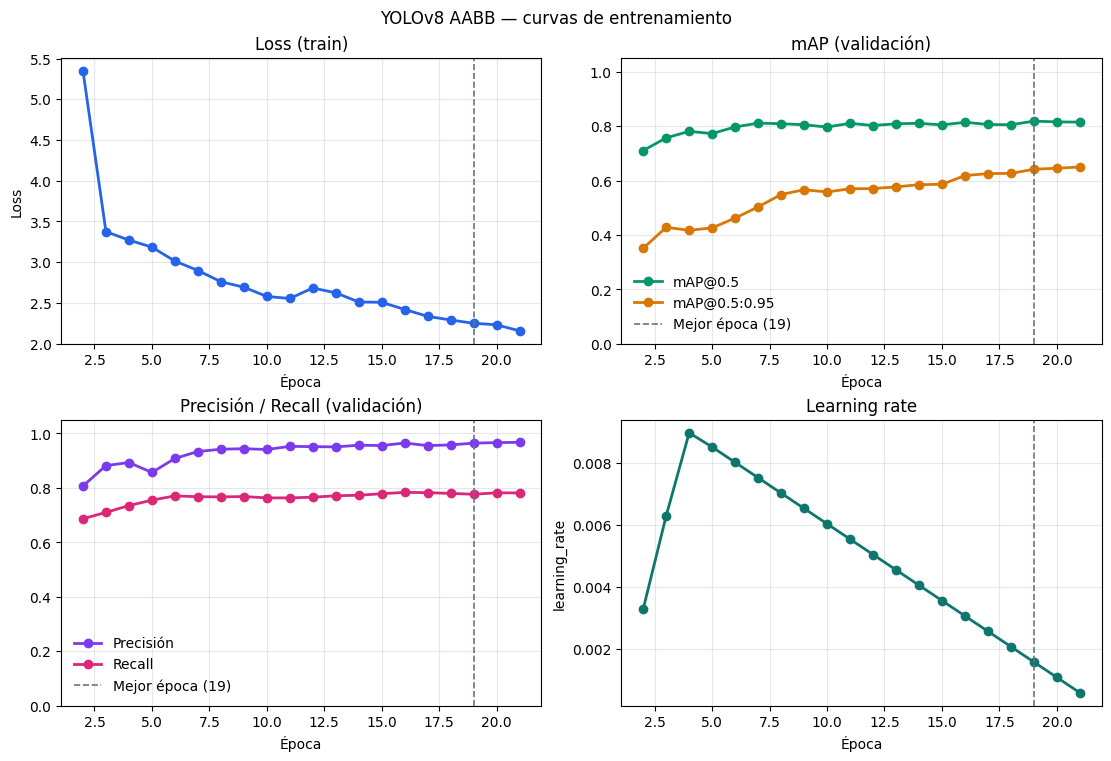

Figura guardada: /content/results/figures/yolov8/curvas_entrenamiento.png
Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2188.1±666.0 MB/s, size: 68.5 KB)
val: Scanning /content/dataset/valid/labels.cache... 271 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 271/271 75.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 17/17 3.8it/s 4.4s0.3s
                   all        271       4622      0.976      0.823      0.822      0.676
Speed: 1.4ms preprocess, 9.9ms inference, 0.0ms loss, 1.3ms postprocess per image

Resumen final (mejor checkpoint en validación)


Métrica,Valor
Época (mejor mAP@0.5 en historial),19
mAP@0.5,0.8221
mAP@0.5:0.95,0.6762
"Precisión (IoU≥0.5, conf≥0.5)",0.9756
"Recall (IoU≥0.5, conf≥0.5)",0.8226
Latencia (ms/imagen),13.5548
FPS (batch=1),73.7746
Dispositivo,cuda
Checkpoint,/content/results/checkpoints/yolov8/mejor_map50.pt



Resumen gráfico (mejor checkpoint)


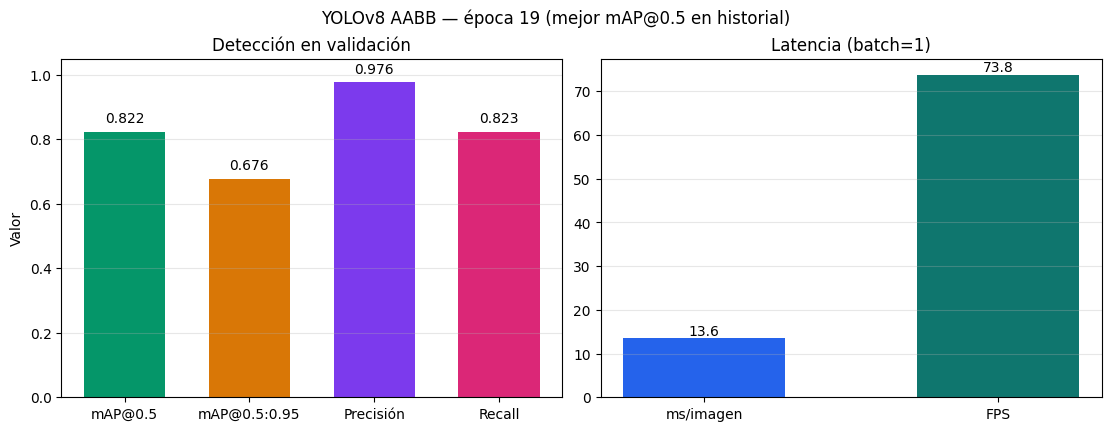

Historial CSV: /content/results/tables/yolov8_historial.csv
Resumen JSON: /content/results/tables/yolov8_resumen_validacion.json
Curvas: /content/results/figures/yolov8/curvas_entrenamiento.png
Resumen gráfico: /content/results/figures/yolov8/resumen_validacion.png
Run Ultralytics: /content/results/ultralytics/yolov8_aabb


In [6]:
import json
import shutil
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from ultralytics import YOLO

# =============================================================================
# HIPERPARÁMETROS DE ESTA CELDA (además de HIPERPARAMETROS del modelo)
# =============================================================================
WARMUP_LATENCIA = 5  # forwards descartados antes de medir ms/imagen
MAX_IMAGENES_LATENCIA = 50  # subset de validación para latencia
# =============================================================================


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def estilo_tabla(df: pd.DataFrame, formatos: dict | None = None):
    estilo = df.style.hide(axis="index")
    if formatos:
        estilo = estilo.format(formatos)
    return estilo.set_table_styles(
        [
            {
                "selector": "th",
                "props": [
                    ("background-color", "#1e293b"),
                    ("color", "#f8fafc"),
                    ("padding", "8px 12px"),
                ],
            },
            {"selector": "td", "props": [("padding", "7px 12px")]},
        ]
    )


def graficar_metricas_entrenamiento(
    historial_df: pd.DataFrame,
    ruta_figura: Path,
    epoca_mejor: int | None = None,
) -> None:
    """Curvas por época: loss, mAP, precisión/recall y learning rate."""
    epocas = historial_df["epoca"]
    figura, ejes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

    def _marca(eje) -> None:
        if epoca_mejor is not None:
            eje.axvline(
                epoca_mejor,
                color="#64748b",
                linestyle="--",
                linewidth=1.2,
                label=f"Mejor época ({epoca_mejor})",
            )

    eje = ejes[0, 0]
    if "loss_train" in historial_df.columns:
        eje.plot(
            epocas,
            historial_df["loss_train"],
            color="#2563eb",
            marker="o",
            linewidth=2,
        )
    eje.set_title("Loss (train)")
    eje.set_xlabel("Época")
    eje.set_ylabel("Loss")
    eje.grid(True, alpha=0.3)
    _marca(eje)

    eje = ejes[0, 1]
    eje.plot(
        epocas, historial_df["map_50"], color="#059669", marker="o", linewidth=2, label="mAP@0.5"
    )
    eje.plot(
        epocas,
        historial_df["map"],
        color="#d97706",
        marker="o",
        linewidth=2,
        label="mAP@0.5:0.95",
    )
    eje.set_title("mAP (validación)")
    eje.set_xlabel("Época")
    eje.set_ylim(0.0, 1.05)
    eje.grid(True, alpha=0.3)
    _marca(eje)
    eje.legend(frameon=False)

    eje = ejes[1, 0]
    eje.plot(
        epocas,
        historial_df["precision_50"],
        color="#7c3aed",
        marker="o",
        linewidth=2,
        label="Precisión",
    )
    eje.plot(
        epocas,
        historial_df["recall_50"],
        color="#db2777",
        marker="o",
        linewidth=2,
        label="Recall",
    )
    eje.set_title("Precisión / Recall (validación)")
    eje.set_xlabel("Época")
    eje.set_ylim(0.0, 1.05)
    eje.grid(True, alpha=0.3)
    _marca(eje)
    eje.legend(frameon=False)

    eje = ejes[1, 1]
    if "learning_rate" in historial_df.columns:
        eje.plot(
            epocas,
            historial_df["learning_rate"],
            color="#0f766e",
            marker="o",
            linewidth=2,
        )
    eje.set_title("Learning rate")
    eje.set_xlabel("Época")
    eje.set_ylabel("learning_rate")
    eje.grid(True, alpha=0.3)
    _marca(eje)

    figura.suptitle("YOLOv8 AABB — curvas de entrenamiento", fontsize=12)
    figura.savefig(ruta_figura, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figura)


def historial_desde_results_csv(ruta_csv: Path) -> pd.DataFrame:
    """Normaliza results.csv de Ultralytics al esquema usado en Faster R-CNN."""
    crudo = pd.read_csv(ruta_csv)
    crudo.columns = [c.strip() for c in crudo.columns]

    def _col(*nombres: str) -> pd.Series:
        for nombre in nombres:
            if nombre in crudo.columns:
                return crudo[nombre]
        return pd.Series([float("nan")] * len(crudo))

    loss_box = _col("train/box_loss")
    loss_cls = _col("train/cls_loss")
    loss_dfl = _col("train/dfl_loss")
    loss_train = loss_box.fillna(0) + loss_cls.fillna(0) + loss_dfl.fillna(0)

    df = pd.DataFrame(
        {
            "epoca": _col("epoch").astype(int) + 1
            if "epoch" in crudo.columns
            else np.arange(1, len(crudo) + 1),
            "loss_train": loss_train,
            "map_50": _col("metrics/mAP50(B)", "metrics/mAP50"),
            "map": _col("metrics/mAP50-95(B)", "metrics/mAP50-95"),
            "precision_50": _col("metrics/precision(B)", "metrics/precision"),
            "recall_50": _col("metrics/recall(B)", "metrics/recall"),
            "learning_rate": _col("lr/pg0", "lr/pg1", "lr0"),
        }
    )
    return df


# --- Dependencias de celdas anteriores ---
try:
    hp = HIPERPARAMETROS
    modelo_ref = modelo
    dispositivo_ref = dispositivo
except NameError as exc:
    raise RuntimeError(
        "Faltan HIPERPARAMETROS / modelo / dispositivo. Ejecutar la celda del modelo."
    ) from exc

try:
    score_eval = float(SCORE_EVAL)
    iou_eval = float(IOU_EVAL)
except NameError:
    score_eval = float(hp["conf_eval"])
    iou_eval = float(hp["iou_eval"])

try:
    directorio_datos = DIRECTORIO_DATASET
except NameError:
    directorio_datos = raiz_del_repo() / "dataset"

try:
    ruta_yaml = RUTA_DATA_YAML
except NameError:
    ruta_yaml = directorio_datos / "data.yaml"
if not Path(ruta_yaml).is_file():
    raise FileNotFoundError(f"No está {ruta_yaml}. Ejecutar la celda del dataset.")

raiz = raiz_del_repo()
directorio_ckpt = raiz / "results" / "checkpoints" / "yolov8"
directorio_tablas = raiz / "results" / "tables"
directorio_figuras = raiz / "results" / "figures" / "yolov8"
directorio_ultra = raiz / "results" / "ultralytics"
directorio_ckpt.mkdir(parents=True, exist_ok=True)
directorio_tablas.mkdir(parents=True, exist_ok=True)
directorio_figuras.mkdir(parents=True, exist_ok=True)
directorio_ultra.mkdir(parents=True, exist_ok=True)

ruta_mejor = directorio_ckpt / "mejor_map50.pt"
ruta_ultimo = directorio_ckpt / "ultimo.pt"
ruta_historial = directorio_tablas / "yolov8_historial.csv"
ruta_resumen = directorio_tablas / "yolov8_resumen_validacion.json"
ruta_figura_metricas = directorio_figuras / "curvas_entrenamiento.png"
ruta_figura_resumen = directorio_figuras / "resumen_validacion.png"

print(f"Dispositivo: {dispositivo_ref}")
if dispositivo_ref.type != "cuda":
    print("AVISO: sin CUDA el entrenamiento completo no es práctico en este set.")
print(
    f"Épocas={hp['epochs']}  batch={hp['batch']}  "
    f"learning_rate={hp['learning_rate']}  imgsz={hp['imgsz']}"
)
print(f"data.yaml: {ruta_yaml}")
print(f"Checkpoints → {directorio_ckpt}")
print(f"Eval protocolo: conf≥{score_eval} IoU≥{iou_eval}\n")

# --- Entrenamiento ---
resultados_train = modelo_ref.train(
    data=str(ruta_yaml),
    epochs=int(hp["epochs"]),
    batch=int(hp["batch"]),
    imgsz=int(hp["imgsz"]),
    device=str(dispositivo_ref) if dispositivo_ref.type == "cuda" else "cpu",
    optimizer=str(hp["optimizer"]),
    lr0=float(hp["learning_rate"]),
    lrf=float(hp["learning_rate_final"]),
    momentum=float(hp["momentum"]),
    weight_decay=float(hp["weight_decay"]),
    seed=int(hp["seed"]),
    patience=int(hp["patience"]),
    single_cls=bool(hp["single_cls"]),
    iou=float(hp["iou"]),
    max_det=int(hp["max_det"]),
    pretrained=True,
    exist_ok=True,
    project=str(directorio_ultra),
    name="yolov8_aabb",
    plots=True,
)

directorio_run = Path(modelo_ref.trainer.save_dir)
ruta_best_ultra = directorio_run / "weights" / "best.pt"
ruta_last_ultra = directorio_run / "weights" / "last.pt"
ruta_results_csv = directorio_run / "results.csv"

if not ruta_best_ultra.is_file():
    raise FileNotFoundError(f"No está el best.pt de Ultralytics en {ruta_best_ultra}")

shutil.copy2(ruta_best_ultra, ruta_mejor)
if ruta_last_ultra.is_file():
    shutil.copy2(ruta_last_ultra, ruta_ultimo)
print(f"Checkpoint mejor → {ruta_mejor}")

# Historial normalizado (mismo esquema conceptual que FRCNN)
if ruta_results_csv.is_file():
    df_hist = historial_desde_results_csv(ruta_results_csv)
    df_hist.to_csv(ruta_historial, index=False)
    print("\nHistorial por época")
    display(
        estilo_tabla(
            df_hist,
            {
                "loss_train": "{:.4f}",
                "map_50": "{:.4f}",
                "map": "{:.4f}",
                "precision_50": "{:.4f}",
                "recall_50": "{:.4f}",
                "learning_rate": "{:.6f}",
            },
        )
    )
    epoca_mejor_hist = int(df_hist.loc[df_hist["map_50"].idxmax(), "epoca"])
    print("\nCurvas de métricas (entrenamiento / validación)")
    graficar_metricas_entrenamiento(
        df_hist,
        ruta_figura_metricas,
        epoca_mejor=epoca_mejor_hist,
    )
    print(f"Figura guardada: {ruta_figura_metricas}")
else:
    df_hist = None
    epoca_mejor_hist = -1
    print(f"AVISO: no está {ruta_results_csv}; se omite historial/curvas.")

# --- Validación explícita con umbrales del protocolo (como FRCNN) ---
modelo_val = YOLO(str(ruta_mejor))
metricas_val = modelo_val.val(
    data=str(ruta_yaml),
    split="val",
    imgsz=int(hp["imgsz"]),
    conf=float(score_eval),
    iou=float(iou_eval),
    device=str(dispositivo_ref) if dispositivo_ref.type == "cuda" else "cpu",
    max_det=int(hp["max_det"]),
    plots=False,
)

box = getattr(metricas_val, "box", None)
map_50 = float(box.map50) if box is not None else float("nan")
map_50_95 = float(box.map) if box is not None else float("nan")
precision_50 = float(box.mp) if box is not None else float("nan")
recall_50 = float(box.mr) if box is not None else float("nan")

# Latencia batch=1 (mismo criterio que FRCNN)
dir_imgs_val = Path(directorio_datos) / "valid" / "images"
rutas_img = sorted(
    [
        p
        for patron in ("*.jpg", "*.jpeg", "*.png")
        for p in dir_imgs_val.glob(patron)
    ]
)[: WARMUP_LATENCIA + MAX_IMAGENES_LATENCIA]

tiempos_ms: list[float] = []
for i, ruta_img in enumerate(rutas_img):
    if dispositivo_ref.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = modelo_val.predict(
        source=str(ruta_img),
        imgsz=int(hp["imgsz"]),
        conf=float(score_eval),
        iou=float(hp["iou"]),
        max_det=int(hp["max_det"]),
        device=str(dispositivo_ref) if dispositivo_ref.type == "cuda" else "cpu",
        verbose=False,
    )
    if dispositivo_ref.type == "cuda":
        torch.cuda.synchronize()
    dt_ms = (time.perf_counter() - t0) * 1000.0
    if i >= WARMUP_LATENCIA:
        tiempos_ms.append(dt_ms)

latencia_ms = float(np.mean(tiempos_ms)) if tiempos_ms else float("nan")
fps = (1000.0 / latencia_ms) if latencia_ms and latencia_ms > 0 else float("nan")

resumen = {
    "dispositivo": str(dispositivo_ref),
    "mejor_epoca": int(epoca_mejor_hist),
    "checkpoint": str(ruta_mejor),
    "map_50": map_50,
    "map_50_95": map_50_95,
    "precision_iou50_score": precision_50,
    "recall_iou50_score": recall_50,
    "score_eval": score_eval,
    "iou_eval": iou_eval,
    "latencia_ms_por_imagen": latencia_ms,
    "fps": fps,
    "hiperparametros": hp,
    "run_ultralytics": str(directorio_run),
}
ruta_resumen.write_text(
    json.dumps(resumen, indent=2, ensure_ascii=False), encoding="utf-8"
)

print("\nResumen final (mejor checkpoint en validación)")
df_resumen = pd.DataFrame(
    [
        {"Métrica": "Época (mejor mAP@0.5 en historial)", "Valor": resumen["mejor_epoca"]},
        {"Métrica": "mAP@0.5", "Valor": resumen["map_50"]},
        {"Métrica": "mAP@0.5:0.95", "Valor": resumen["map_50_95"]},
        {
            "Métrica": f"Precisión (IoU≥{iou_eval}, conf≥{score_eval})",
            "Valor": resumen["precision_iou50_score"],
        },
        {
            "Métrica": f"Recall (IoU≥{iou_eval}, conf≥{score_eval})",
            "Valor": resumen["recall_iou50_score"],
        },
        {"Métrica": "Latencia (ms/imagen)", "Valor": resumen["latencia_ms_por_imagen"]},
        {"Métrica": "FPS (batch=1)", "Valor": resumen["fps"]},
        {"Métrica": "Dispositivo", "Valor": resumen["dispositivo"]},
        {"Métrica": "Checkpoint", "Valor": resumen["checkpoint"]},
    ]
)
display(
    estilo_tabla(
        df_resumen,
        {
            "Valor": lambda x: (
                f"{x:.4f}" if isinstance(x, float) else str(x)
            )
        },
    )
)

print("\nResumen gráfico (mejor checkpoint)")
etiquetas = ["mAP@0.5", "mAP@0.5:0.95", "Precisión", "Recall"]
valores = [
    resumen["map_50"],
    resumen["map_50_95"],
    resumen["precision_iou50_score"],
    resumen["recall_iou50_score"],
]
colores = ["#059669", "#d97706", "#7c3aed", "#db2777"]
figura_r, (eje_m, eje_l) = plt.subplots(1, 2, figsize=(11, 4.2), constrained_layout=True)
barras = eje_m.bar(etiquetas, valores, color=colores, width=0.65)
eje_m.set_ylim(0.0, 1.05)
eje_m.set_ylabel("Valor")
eje_m.set_title("Detección en validación")
eje_m.grid(True, axis="y", alpha=0.3)
for barra, valor in zip(barras, valores):
    eje_m.text(
        barra.get_x() + barra.get_width() / 2,
        valor + 0.02,
        f"{valor:.3f}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
eje_l.bar(
    ["ms/imagen", "FPS"],
    [resumen["latencia_ms_por_imagen"], resumen["fps"]],
    color=["#2563eb", "#0f766e"],
    width=0.55,
)
eje_l.set_title("Latencia (batch=1)")
eje_l.grid(True, axis="y", alpha=0.3)
for i, valor in enumerate([resumen["latencia_ms_por_imagen"], resumen["fps"]]):
    eje_l.text(i, valor, f"{valor:.1f}", ha="center", va="bottom", fontsize=10)
figura_r.suptitle(
    f"YOLOv8 AABB — época {resumen['mejor_epoca']} (mejor mAP@0.5 en historial)",
    fontsize=12,
)
figura_r.savefig(ruta_figura_resumen, dpi=150, bbox_inches="tight")
plt.show()
plt.close(figura_r)

print(f"Historial CSV: {ruta_historial}")
print(f"Resumen JSON: {ruta_resumen}")
print(f"Curvas: {ruta_figura_metricas}")
print(f"Resumen gráfico: {ruta_figura_resumen}")
print(f"Run Ultralytics: {directorio_run}")


### Lectura: resultados del entrenamiento

Corrida de 20 épocas en *CUDA* (Colab, Tesla T4), batch 16, *learning_rate* inicial 0,01 (*SGD*), transfer learning desde COCO con *YOLOv8s*. El checkpoint elegido es el de mayor *mAP@0.5* en el historial de validación: **época 19**. Reevaluación con el protocolo (*conf* ≥ 0,5, *IoU* ≥ 0,5): *mAP@0.5* = 0,822; *mAP@0.5:0.95* = 0,676; precisión = 0,976; recall = 0,823; ~14 ms/imagen ≈ 74 FPS (batch=1).

**Curvas**

- La *loss* de entrenamiento baja de forma sostenida a lo largo de las 20 épocas: el optimizador sigue aprendiendo hasta el final.
- El *mAP@0.5* del historial sube con oscilaciones hasta la época 19 (~0,818) y en la 20 no mejora. Ese es el corte que copia Ultralytics a *best.pt*.
- El *mAP@0.5:0.95* sigue subiendo hasta el final (~0,65): las cajas se afinan aunque el conteo a IoU 0,5 ya casi no gana.
- Precisión alta desde temprano (~0,90–0,97); el recall se estabiliza cerca de ~0,77–0,78 en el historial y sube a ~0,82 en la reevaluación con umbrales fijos. El cuello de botella sigue siendo **dejar lomos sin detectar**, no inventar demasiados falsos positivos a *conf* ≥ 0,5.
- El *learning_rate* decae con el *lrf* de Ultralytics (final ≈ 1 % del inicial): coincide con la fase en que el *mAP@0.5:0.95* gana más que el *mAP@0.5*.

**Qué implica para el detector**

- El transfer learning funciona: ya en las primeras épocas el *mAP@0.5* supera 0,70 y hacia la mitad del entrenamiento ronda 0,80.
- El modelo es **preciso pero incompleto** a umbral 0,5: útil si se prioriza no inventar lomos; peor si el pipeline (OCR) necesita alto recall en estantes densos.
- Elegir por *mAP@0.5* (época 19) privilegia detección “sí/no”; un criterio solo por *mAP@0.5:0.95* habría mirado las últimas épocas, con cajas más justas.
- ~74 FPS en T4 alcanza holgado para demo por imagen y deja margen frente a Faster R-CNN (~10 FPS en el mismo tipo de hardware).

**Límites de esta lectura**

- Las métricas son de **validación global**. No separan estantes densos ni lomos inclinados (fallos que el EDA marcó como críticos).
- El split de Roboflow tiene leakage por foto fuente: el *mAP* absoluto puede estar algo inflado; la comparación vs. Faster R-CNN sigue siendo válida si ambos usan el mismo corte.
- La visualización cualitativa, el chequeo en *test* y los subconjuntos denso/inclinado usan el mismo checkpoint.


## 6. Visualización cualitativa (validación)

La celda siguiente carga el mejor checkpoint (*mejor_map50.pt*) e infiere sobre el split de validación. Empareja cajas predichas y GT con el mismo criterio de las métricas (*conf* ≥ 0,5 e *IoU* ≥ 0,5) y clasifica cada caja como *TP*, *FP* o *FN*.

Con semilla fija arma una muestra: imágenes aleatorias, las de mayor cantidad de *FN* y las de mayor cantidad de *FP*. Por cada imagen muestra dos paneles — anotación GT y predicción coloreada — y guarda las figuras en *results/figures/yolov8/cualitativo/*. No reentrena ni toca *test*.

Checkpoint: mejor_map50.pt | validación: 271 imágenes | conf≥0.5 IoU≥0.5


Conteos validación (viz):   0%|          | 0/271 [00:00<?, ?it/s]


Resumen por imagen (validación)


,n_gt,tp,fp,fn,recall
count,271.000,271.000,271.000,271.000,269.000
mean,17.055,13.044,0.469,4.011,0.803
std,9.525,6.998,1.763,6.004,0.211
min,0.000,0.000,0.000,0.000,0.286
25%,11.000,7.000,0.000,0.000,0.667
50%,17.000,12.000,0.000,2.000,0.867
75%,22.000,18.000,0.000,5.000,1.000
max,67.000,33.000,19.000,44.000,1.000



Figuras a generar: 10


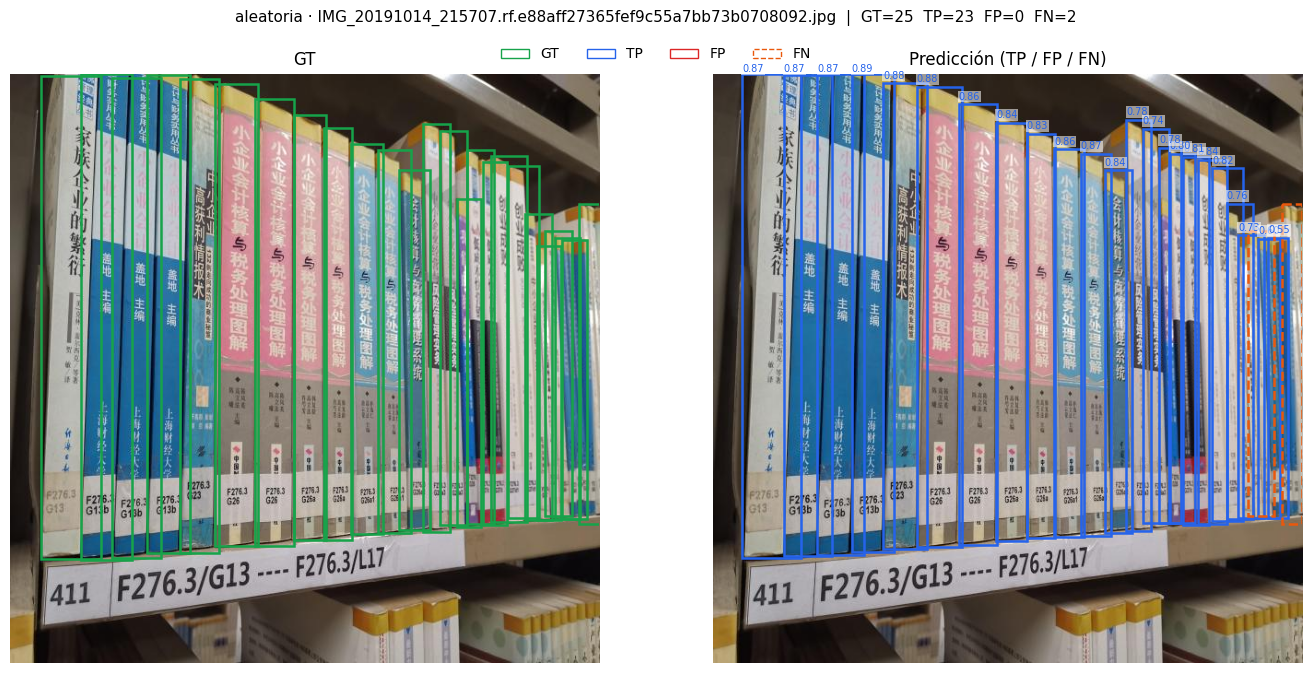

  guardada: results/figures/yolov8/cualitativo/01_aleatoria_id57.png


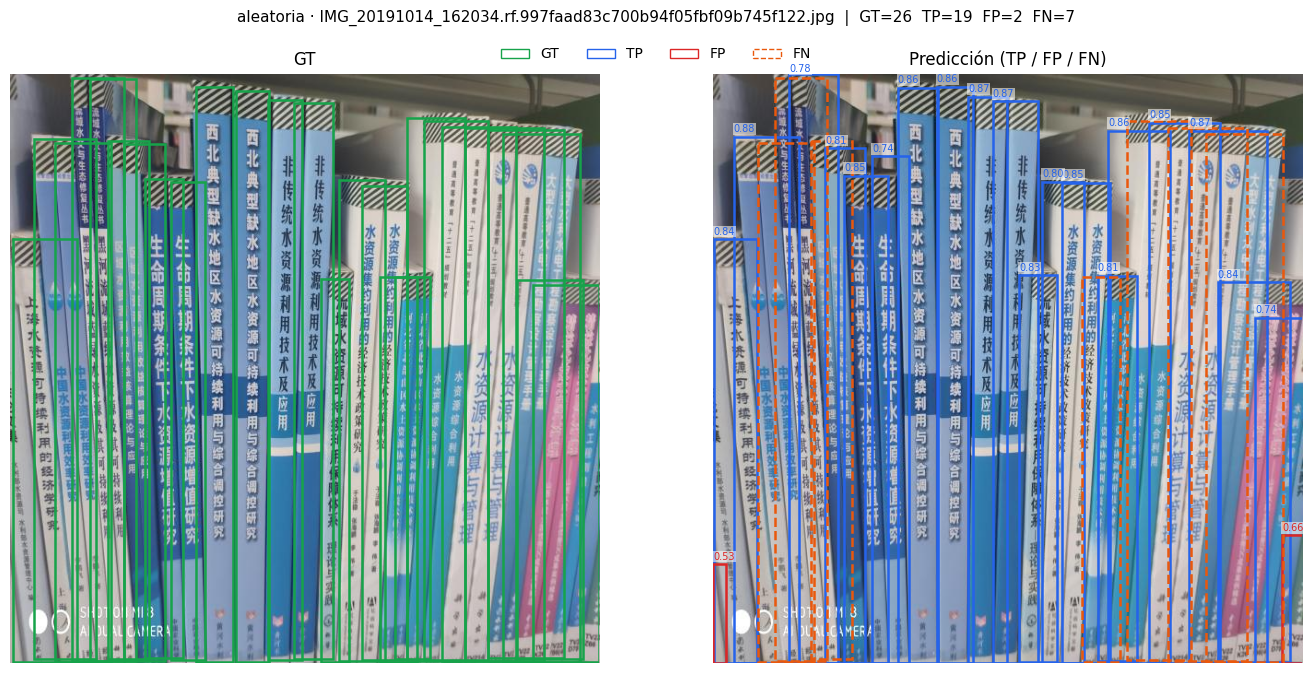

  guardada: results/figures/yolov8/cualitativo/02_aleatoria_id12.png


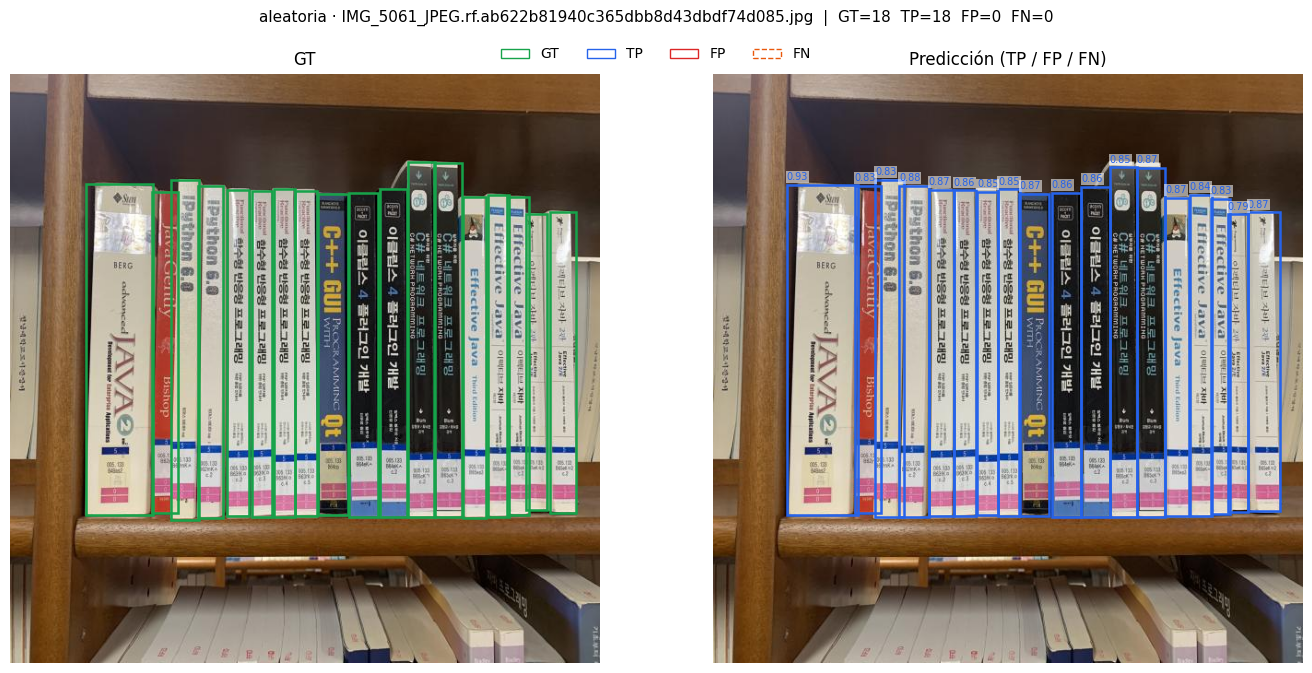

  guardada: results/figures/yolov8/cualitativo/03_aleatoria_id140.png


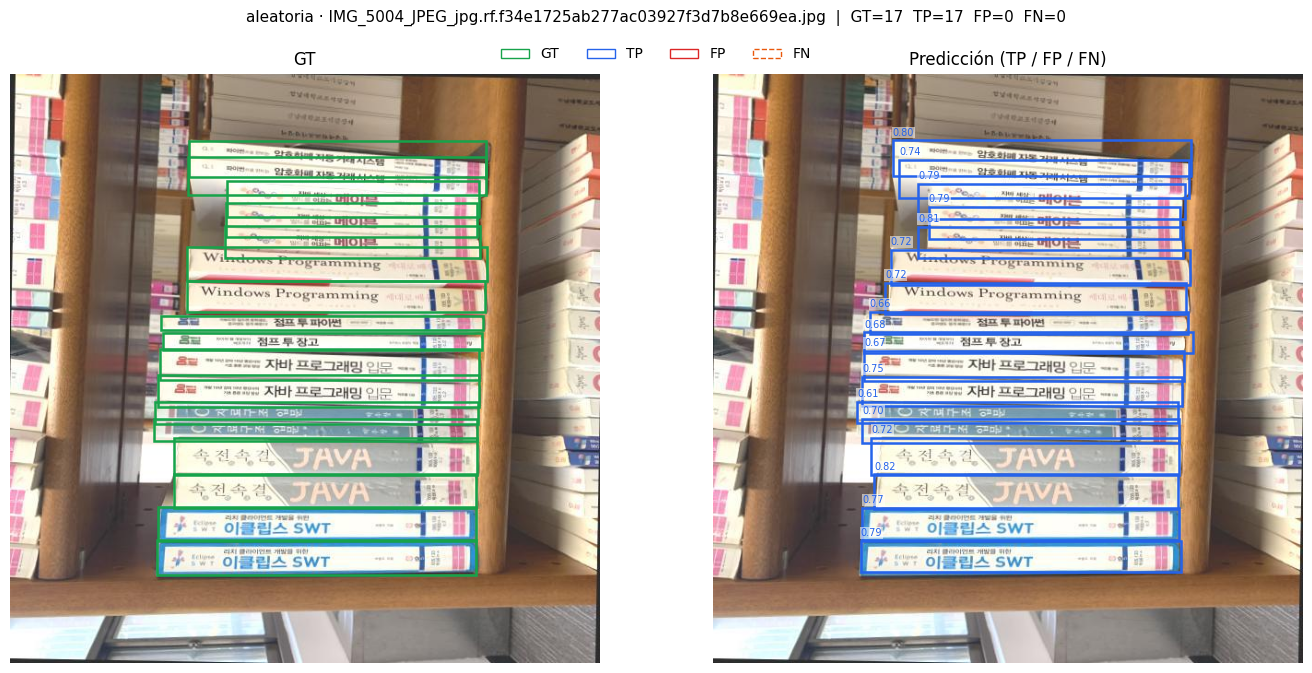

  guardada: results/figures/yolov8/cualitativo/04_aleatoria_id125.png


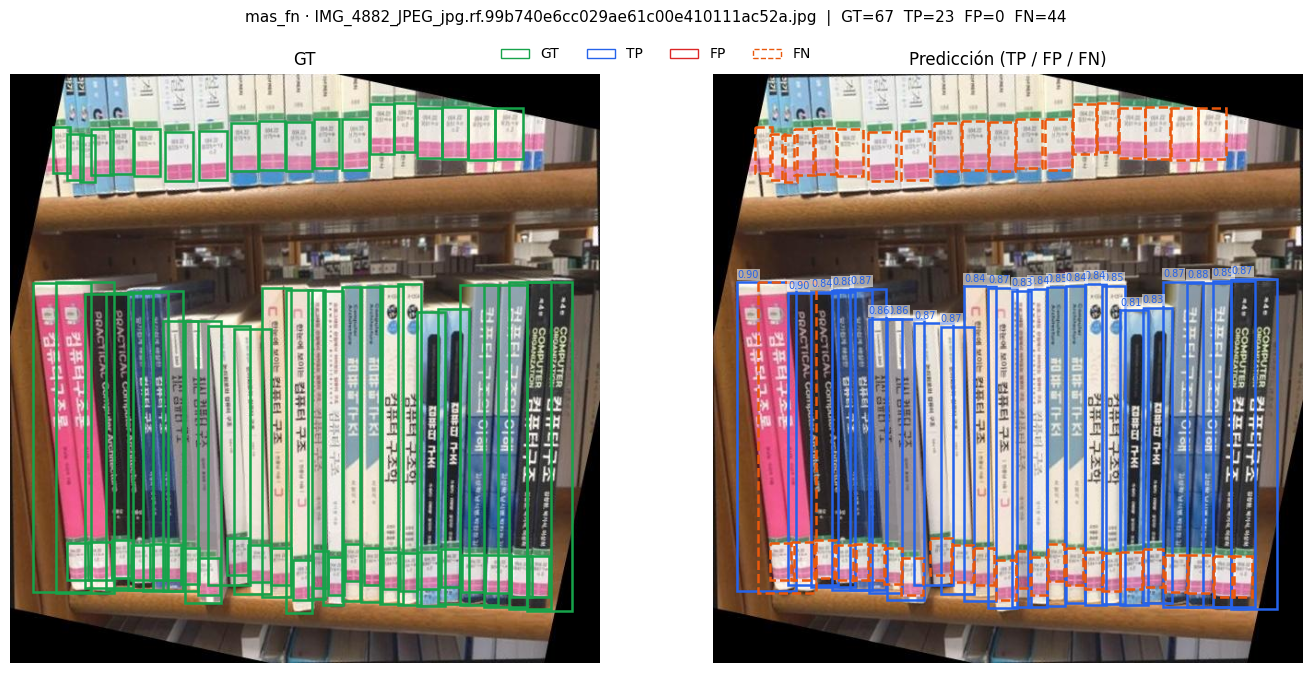

  guardada: results/figures/yolov8/cualitativo/05_mas_fn_id104.png


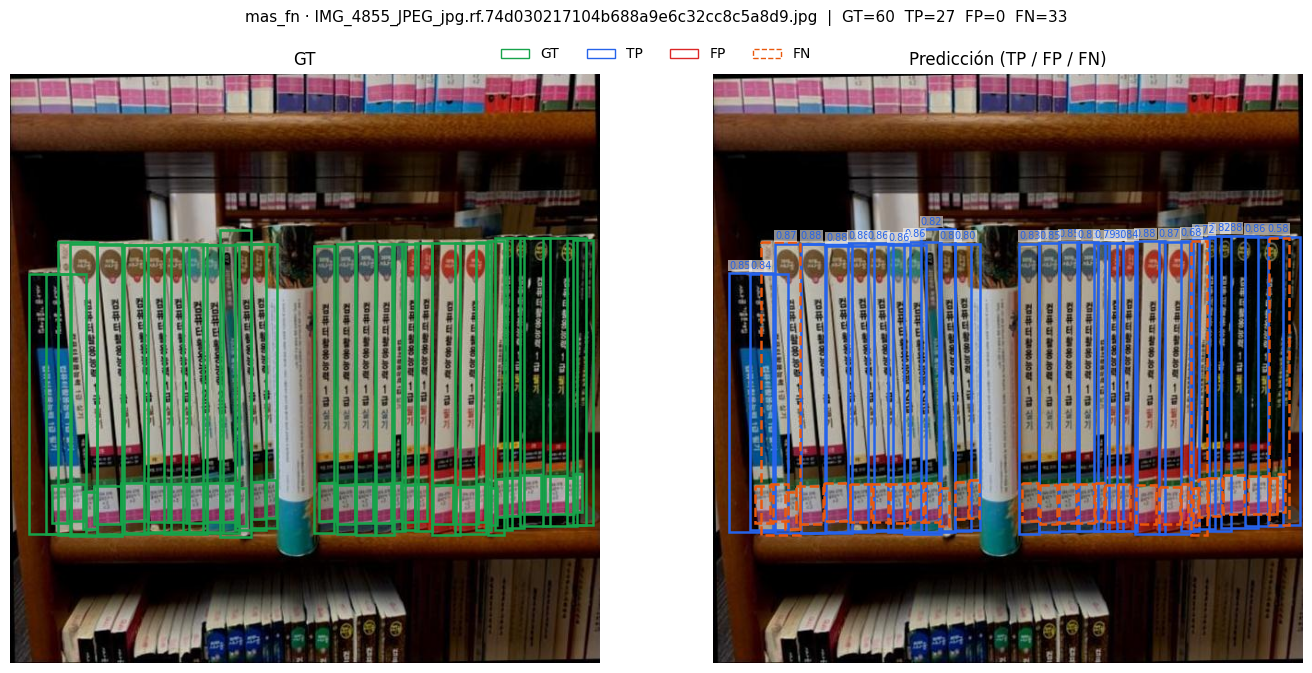

  guardada: results/figures/yolov8/cualitativo/06_mas_fn_id95.png


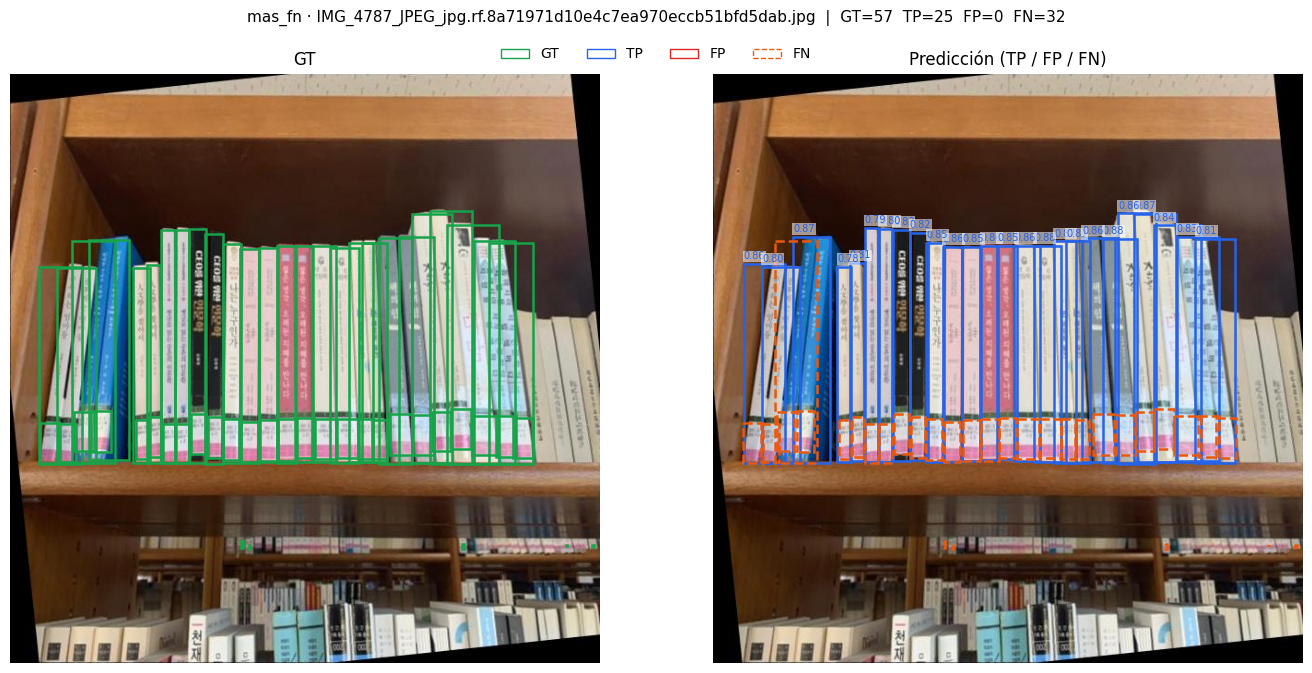

  guardada: results/figures/yolov8/cualitativo/07_mas_fn_id74.png


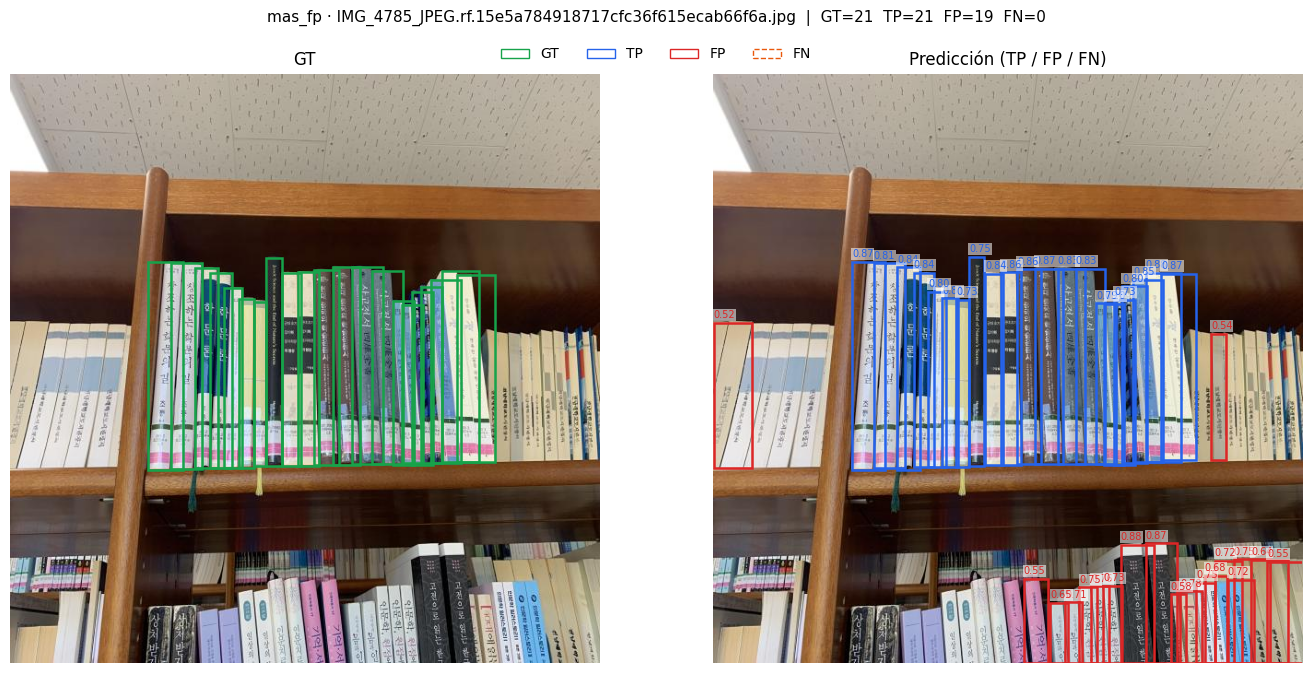

  guardada: results/figures/yolov8/cualitativo/08_mas_fp_id73.png


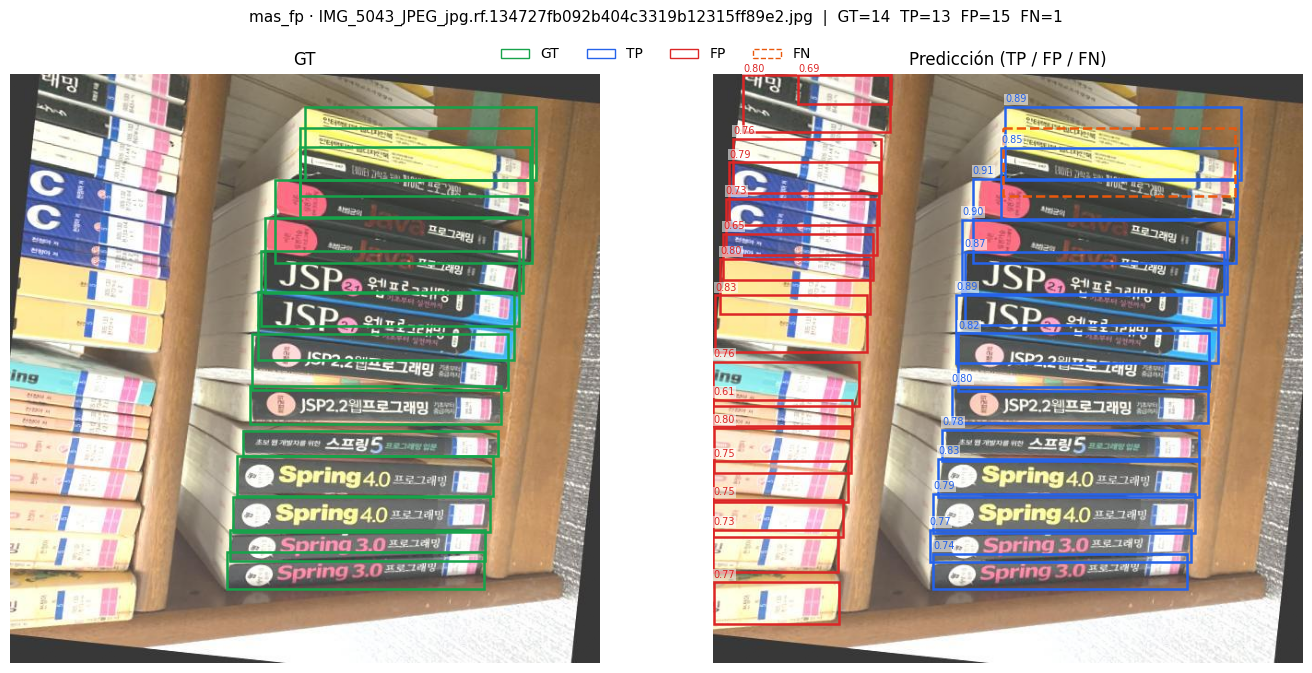

  guardada: results/figures/yolov8/cualitativo/09_mas_fp_id137.png


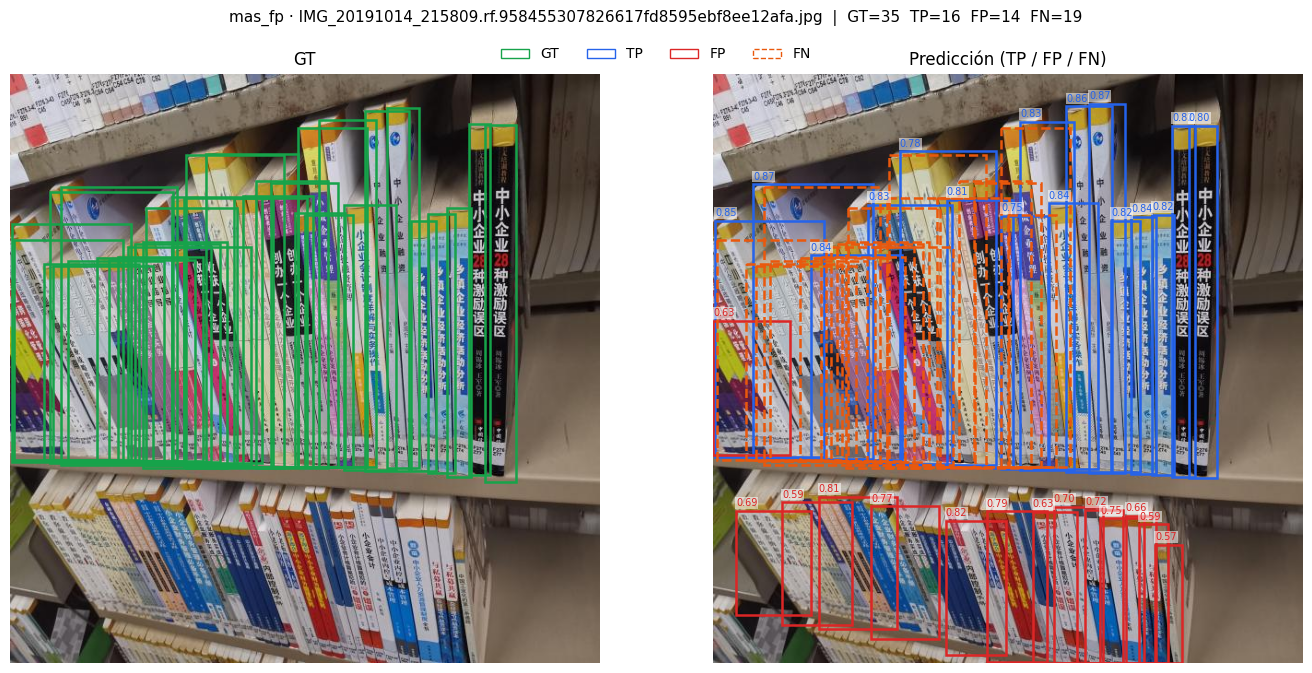

  guardada: results/figures/yolov8/cualitativo/10_mas_fp_id59.png

Listo: 10 figuras en results/figures/yolov8/cualitativo


In [7]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from matplotlib.patches import Patch, Rectangle
from PIL import Image
from tqdm.auto import tqdm
from ultralytics import YOLO

# =============================================================================
# Parámetros de la visualización cualitativa
# =============================================================================
SEMILLA_VIZ = 42
N_ALEATORIAS = 4
N_MAS_FN = 3
N_MAS_FP = 3
SCORE_VIZ = float(SCORE_EVAL) if "SCORE_EVAL" in globals() else 0.5
IOU_VIZ = float(IOU_EVAL) if "IOU_EVAL" in globals() else 0.5
GROSOR_CAJA = 1.8

COLORES = {
    "gt": "#16a34a",
    "tp": "#2563eb",
    "fp": "#dc2626",
    "fn": "#ea580c",
}


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def iou_matriz(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    """IoU entre cajas a (N,4) y b (M,4) en xyxy."""
    if a.numel() == 0 or b.numel() == 0:
        return torch.zeros((a.shape[0], b.shape[0]), device=a.device)
    area_a = (a[:, 2] - a[:, 0]).clamp(min=0) * (a[:, 3] - a[:, 1]).clamp(min=0)
    area_b = (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
    lt = torch.max(a[:, None, :2], b[None, :, :2])
    rb = torch.min(a[:, None, 2:], b[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union.clamp(min=1e-6)


def clasificar_detecciones(
    cajas_pred: torch.Tensor,
    scores: torch.Tensor,
    cajas_gt: torch.Tensor,
    score_min: float,
    iou_min: float,
) -> dict[str, torch.Tensor]:
    """Matching guloso: TP / FP (pred) y FN (GT sin pareja)."""
    keep = scores >= score_min
    cajas_pred = cajas_pred[keep]
    scores = scores[keep]
    dispositivo = cajas_gt.device if cajas_gt.numel() else cajas_pred.device

    if cajas_pred.numel() == 0:
        vacio = torch.zeros((0, 4), device=dispositivo)
        return {
            "tp": vacio,
            "fp": vacio,
            "fn": cajas_gt.clone() if cajas_gt.numel() else vacio,
            "scores_tp": torch.zeros((0,), device=dispositivo),
            "scores_fp": torch.zeros((0,), device=dispositivo),
        }

    orden = scores.argsort(descending=True)
    cajas_pred = cajas_pred[orden]
    scores = scores[orden]

    if cajas_gt.numel() == 0:
        vacio = torch.zeros((0, 4), device=dispositivo)
        return {
            "tp": vacio,
            "fp": cajas_pred,
            "fn": vacio,
            "scores_tp": torch.zeros((0,), device=dispositivo),
            "scores_fp": scores,
        }

    ious = iou_matriz(cajas_pred, cajas_gt)
    gt_usado = torch.zeros(cajas_gt.shape[0], dtype=torch.bool, device=dispositivo)
    es_tp = torch.zeros(cajas_pred.shape[0], dtype=torch.bool, device=dispositivo)
    for i in range(cajas_pred.shape[0]):
        iou_i, j = ious[i].max(dim=0)
        if iou_i >= iou_min and not gt_usado[j]:
            es_tp[i] = True
            gt_usado[j] = True

    return {
        "tp": cajas_pred[es_tp],
        "fp": cajas_pred[~es_tp],
        "fn": cajas_gt[~gt_usado],
        "scores_tp": scores[es_tp],
        "scores_fp": scores[~es_tp],
    }


def cajas_gt_desde_label_yolo(
    ruta_etiqueta: Path, ancho: int, alto: int
) -> torch.Tensor:
    """Lee label YOLO (caja cxcywh o polígono) y devuelve cajas xyxy en píxeles."""
    if not ruta_etiqueta.is_file():
        return torch.zeros((0, 4), dtype=torch.float32)

    cajas: list[list[float]] = []
    for linea in ruta_etiqueta.read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea.startswith("#"):
            continue
        partes = linea.split()
        if len(partes) < 5:
            continue
        valores = [float(p) for p in partes[1:]]
        if len(valores) == 4:
            cx, cy, w, h = valores
            x0 = (cx - w / 2.0) * ancho
            y0 = (cy - h / 2.0) * alto
            x1 = (cx + w / 2.0) * ancho
            y1 = (cy + h / 2.0) * alto
        else:
            if len(valores) < 6 or len(valores) % 2 != 0:
                continue
            coords = np.array(valores, dtype=float).reshape(-1, 2)
            xmin, ymin = coords.min(axis=0)
            xmax, ymax = coords.max(axis=0)
            x0, y0, x1, y1 = xmin * ancho, ymin * alto, xmax * ancho, ymax * alto
        if x1 <= x0 or y1 <= y0:
            continue
        cajas.append([x0, y0, x1, y1])

    if not cajas:
        return torch.zeros((0, 4), dtype=torch.float32)
    return torch.tensor(cajas, dtype=torch.float32)


def dibujar_cajas(
    eje,
    cajas: torch.Tensor,
    color: str,
    scores: torch.Tensor | None = None,
    estilo_linea: str = "-",
) -> None:
    if cajas is None or cajas.numel() == 0:
        return
    cajas_np = cajas.detach().cpu().numpy()
    scores_np = (
        scores.detach().cpu().numpy() if scores is not None and scores.numel() else None
    )
    for i, (x0, y0, x1, y1) in enumerate(cajas_np):
        eje.add_patch(
            Rectangle(
                (x0, y0),
                x1 - x0,
                y1 - y0,
                fill=False,
                edgecolor=color,
                linewidth=GROSOR_CAJA,
                linestyle=estilo_linea,
            )
        )
        if scores_np is not None:
            eje.text(
                x0,
                max(y0 - 3, 0),
                f"{scores_np[i]:.2f}",
                color=color,
                fontsize=7,
                va="bottom",
                ha="left",
                bbox={
                    "facecolor": "white",
                    "alpha": 0.55,
                    "edgecolor": "none",
                    "pad": 0.6,
                },
            )


def graficar_par_gt_pred(
    imagen_np: np.ndarray,
    cajas_gt: torch.Tensor,
    clases: dict[str, torch.Tensor],
    titulo: str,
    ruta_salida: Path,
) -> None:
    figura, ejes = plt.subplots(1, 2, figsize=(14, 6.2), constrained_layout=True)
    eje_gt, eje_pred = ejes

    eje_gt.imshow(imagen_np)
    eje_gt.set_title("GT")
    eje_gt.axis("off")
    dibujar_cajas(eje_gt, cajas_gt, COLORES["gt"])

    eje_pred.imshow(imagen_np)
    eje_pred.set_title("Predicción (TP / FP / FN)")
    eje_pred.axis("off")
    dibujar_cajas(eje_pred, clases["tp"], COLORES["tp"], clases["scores_tp"])
    dibujar_cajas(eje_pred, clases["fp"], COLORES["fp"], clases["scores_fp"])
    dibujar_cajas(eje_pred, clases["fn"], COLORES["fn"], estilo_linea="--")

    leyenda = [
        Patch(edgecolor=COLORES["gt"], facecolor="none", label="GT"),
        Patch(edgecolor=COLORES["tp"], facecolor="none", label="TP"),
        Patch(edgecolor=COLORES["fp"], facecolor="none", label="FP"),
        Patch(
            edgecolor=COLORES["fn"],
            facecolor="none",
            linestyle="--",
            label="FN",
        ),
    ]
    figura.legend(
        handles=leyenda,
        loc="upper center",
        ncol=4,
        frameon=False,
        bbox_to_anchor=(0.5, 1.02),
    )
    n_gt = int(cajas_gt.shape[0])
    n_tp = int(clases["tp"].shape[0])
    n_fp = int(clases["fp"].shape[0])
    n_fn = int(clases["fn"].shape[0])
    figura.suptitle(
        f"{titulo}  |  GT={n_gt}  TP={n_tp}  FP={n_fp}  FN={n_fn}",
        fontsize=11,
        y=1.06,
    )
    figura.savefig(ruta_salida, dpi=140, bbox_inches="tight")
    plt.show()
    plt.close(figura)


def prediccion_yolo_a_tensores(resultado) -> tuple[torch.Tensor, torch.Tensor]:
    """Extrae boxes xyxy y scores del Result de Ultralytics."""
    boxes = resultado.boxes
    if boxes is None or len(boxes) == 0:
        vacio_b = torch.zeros((0, 4), dtype=torch.float32)
        vacio_s = torch.zeros((0,), dtype=torch.float32)
        return vacio_b, vacio_s
    cajas = boxes.xyxy.detach().cpu().float()
    scores = boxes.conf.detach().cpu().float()
    return cajas, scores


# --- Dependencias / rutas ---
try:
    hp_viz = HIPERPARAMETROS
except NameError:
    hp_viz = {"imgsz": 640, "iou": 0.40, "max_det": 300}

try:
    dispositivo_viz = dispositivo
except NameError:
    dispositivo_viz = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    directorio_datos = DIRECTORIO_DATASET
except NameError:
    directorio_datos = raiz_del_repo() / "dataset"

raiz = raiz_del_repo()
directorio_ckpt = raiz / "results" / "checkpoints" / "yolov8"
directorio_figuras_viz = raiz / "results" / "figures" / "yolov8" / "cualitativo"
directorio_figuras_viz.mkdir(parents=True, exist_ok=True)
ruta_mejor_viz = directorio_ckpt / "mejor_map50.pt"

if not ruta_mejor_viz.is_file():
    raise FileNotFoundError(
        f"No está el checkpoint {ruta_mejor_viz}. Ejecutar antes el entrenamiento."
    )

modelo_viz = YOLO(str(ruta_mejor_viz))
dir_imgs = Path(directorio_datos) / "valid" / "images"
dir_labels = Path(directorio_datos) / "valid" / "labels"
rutas_imagenes = sorted(
    [
        p
        for patron in ("*.jpg", "*.jpeg", "*.png")
        for p in dir_imgs.glob(patron)
    ]
)
if not rutas_imagenes:
    raise FileNotFoundError(f"No hay imágenes en {dir_imgs}")

print(
    f"Checkpoint: {ruta_mejor_viz.name} | validación: {len(rutas_imagenes)} imágenes | "
    f"conf≥{SCORE_VIZ} IoU≥{IOU_VIZ}"
)

# Barrido 1: solo conteos TP/FP/FN
filas_resumen: list[dict] = []
nombre_por_idx: dict[int, str] = {}

for idx, ruta_img in enumerate(tqdm(rutas_imagenes, desc="Conteos validación (viz)")):
    with Image.open(ruta_img) as im:
        ancho, alto = im.size
    ruta_lbl = dir_labels / f"{ruta_img.stem}.txt"
    cajas_gt = cajas_gt_desde_label_yolo(ruta_lbl, ancho, alto)

    resultado = modelo_viz.predict(
        source=str(ruta_img),
        imgsz=int(hp_viz.get("imgsz", 640)),
        conf=float(SCORE_VIZ),
        iou=float(hp_viz.get("iou", 0.40)),
        max_det=int(hp_viz.get("max_det", 300)),
        device=str(dispositivo_viz) if dispositivo_viz.type == "cuda" else "cpu",
        verbose=False,
    )[0]
    cajas_pred, scores_pred = prediccion_yolo_a_tensores(resultado)
    clases = clasificar_detecciones(
        cajas_pred,
        scores_pred,
        cajas_gt,
        score_min=SCORE_VIZ,
        iou_min=IOU_VIZ,
    )
    n_tp = int(clases["tp"].shape[0])
    n_fp = int(clases["fp"].shape[0])
    n_fn = int(clases["fn"].shape[0])
    n_gt = int(cajas_gt.shape[0])
    recall_img = (n_tp / n_gt) if n_gt else float("nan")
    filas_resumen.append(
        {
            "image_id": idx,
            "n_gt": n_gt,
            "tp": n_tp,
            "fp": n_fp,
            "fn": n_fn,
            "recall": recall_img,
        }
    )
    nombre_por_idx[idx] = ruta_img.name

df_viz = pd.DataFrame(filas_resumen).sort_values("image_id").reset_index(drop=True)
print("\nResumen por imagen (validación)")
display(
    df_viz[["n_gt", "tp", "fp", "fn", "recall"]]
    .describe()
    .style.format("{:.3f}")
)

# Selección (semilla fija): aleatorias + más FN + más FP
rng = random.Random(SEMILLA_VIZ)
ids_todos = df_viz["image_id"].tolist()
ids_aleatorios = rng.sample(ids_todos, k=min(N_ALEATORIAS, len(ids_todos)))
ids_fn = (
    df_viz.sort_values(["fn", "n_gt"], ascending=[False, False])["image_id"]
    .head(N_MAS_FN)
    .tolist()
)
ids_fp = (
    df_viz.sort_values(["fp", "n_gt"], ascending=[False, False])["image_id"]
    .head(N_MAS_FP)
    .tolist()
)

seleccion: list[tuple[str, int]] = []
vistos: set[int] = set()
for etiqueta, lista in (
    ("aleatoria", ids_aleatorios),
    ("mas_fn", ids_fn),
    ("mas_fp", ids_fp),
):
    for id_img in lista:
        if id_img in vistos:
            continue
        vistos.add(id_img)
        seleccion.append((etiqueta, id_img))

# Barrido 2: re-inferir solo las seleccionadas y graficar
print(f"\nFiguras a generar: {len(seleccion)}")
rutas_guardadas: list[Path] = []
for i, (etiqueta, id_img) in enumerate(seleccion, start=1):
    ruta_img = rutas_imagenes[id_img]
    with Image.open(ruta_img) as im:
        imagen_np = np.asarray(im.convert("RGB"), dtype=np.float32) / 255.0
        ancho, alto = im.size
    ruta_lbl = dir_labels / f"{ruta_img.stem}.txt"
    cajas_gt = cajas_gt_desde_label_yolo(ruta_lbl, ancho, alto)

    resultado = modelo_viz.predict(
        source=str(ruta_img),
        imgsz=int(hp_viz.get("imgsz", 640)),
        conf=float(SCORE_VIZ),
        iou=float(hp_viz.get("iou", 0.40)),
        max_det=int(hp_viz.get("max_det", 300)),
        device=str(dispositivo_viz) if dispositivo_viz.type == "cuda" else "cpu",
        verbose=False,
    )[0]
    cajas_pred, scores_pred = prediccion_yolo_a_tensores(resultado)
    clases = clasificar_detecciones(
        cajas_pred,
        scores_pred,
        cajas_gt,
        score_min=SCORE_VIZ,
        iou_min=IOU_VIZ,
    )

    nombre = nombre_por_idx.get(id_img, ruta_img.name)
    titulo = f"{etiqueta} · {nombre}"
    ruta = directorio_figuras_viz / f"{i:02d}_{etiqueta}_id{id_img}.png"
    graficar_par_gt_pred(
        imagen_np,
        cajas_gt,
        clases,
        titulo=titulo,
        ruta_salida=ruta,
    )
    rutas_guardadas.append(ruta)
    print(f"  guardada: {ruta.relative_to(raiz)}")

print(f"\nListo: {len(rutas_guardadas)} figuras en {directorio_figuras_viz.relative_to(raiz)}")


## 7. Chequeo en *test*

La celda siguiente evalúa el mejor checkpoint (*mAP@0.5* en validación) sobre el split de *test*, con los mismos umbrales de *conf* e *IoU* que en validación. No ajusta hiperparámetros.

Reporta *mAP@0.5*, *mAP@0.5:0.95*, precisión, recall y latencia (*ms/imagen*, *FPS* con batch=1). Si existe el resumen de validación, arma la comparación val vs test y guarda la figura en *results/figures/yolov8/*. El JSON de cierre queda en *results/tables/yolov8_resumen_test.json*.

Checkpoint: mejor_map50.pt (época 19) | test: 120 imágenes | conf≥0.5 IoU≥0.5
Sin ajuste de hiperparámetros: pasada única de cierre.

Ultralytics 8.4.157 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 11,125,971 parameters, 0 gradients, 28.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 981.7±399.5 MB/s, size: 53.1 KB)
val: Scanning /content/dataset/test/labels... 120 images, 3 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 120/120 937.3it/s 0.1s1s
val: New cache created: /content/dataset/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 3.2it/s 2.5s0.3ss
                   all        120       1747      0.978      0.825      0.822      0.665
Speed: 1.6ms preprocess, 10.2ms inference, 0.0ms loss, 1.6ms postprocess per image
Resumen en test (mejor checkpoint de validación)


Métrica,Valor
Época (checkpoint val),19
Imágenes (test),120
mAP@0.5,0.8219
mAP@0.5:0.95,0.6647
"Precisión (IoU≥0.5, conf≥0.5)",0.9783
"Recall (IoU≥0.5, conf≥0.5)",0.8254
Latencia (ms/imagen),13.9231
FPS (batch=1),71.8231
Checkpoint,/content/results/checkpoints/yolov8/mejor_map50.pt



Validación vs. test (mismo checkpoint)


Métrica,Validación,Test
mAP@0.5,0.8221,0.8219
mAP@0.5:0.95,0.6762,0.6647
Precisión,0.9756,0.9783
Recall,0.8226,0.8254
Latencia (ms),13.5548,13.9231
FPS,73.7746,71.8231


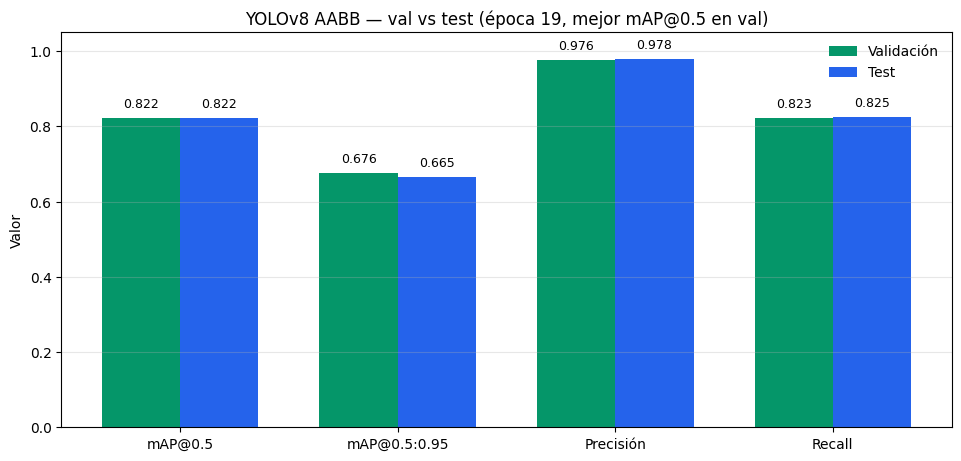

Figura: /content/results/figures/yolov8/comparacion_val_test.png
Resumen JSON test: /content/results/tables/yolov8_resumen_test.json


In [8]:
import json
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from ultralytics import YOLO


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def estilo_tabla_test(df: pd.DataFrame, formatos: dict | None = None):
    if "estilo_tabla" in globals():
        return estilo_tabla(df, formatos)
    estilo = df.style.hide(axis="index")
    if formatos:
        estilo = estilo.format(formatos)
    return estilo


# --- Dependencias ---
try:
    hp_te = HIPERPARAMETROS
except NameError:
    hp_te = {
        "imgsz": 640,
        "iou": 0.40,
        "max_det": 300,
    }

try:
    dispositivo_te = dispositivo
except NameError:
    dispositivo_te = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    directorio_datos = DIRECTORIO_DATASET
except NameError:
    directorio_datos = raiz_del_repo() / "dataset"

try:
    ruta_yaml = RUTA_DATA_YAML
except NameError:
    ruta_yaml = Path(directorio_datos) / "data.yaml"
if not Path(ruta_yaml).is_file():
    raise FileNotFoundError(f"No está {ruta_yaml}. Ejecutar la celda del dataset.")

score_te = float(SCORE_EVAL) if "SCORE_EVAL" in globals() else 0.5
iou_te = float(IOU_EVAL) if "IOU_EVAL" in globals() else 0.5
warmup_te = int(WARMUP_LATENCIA) if "WARMUP_LATENCIA" in globals() else 5
max_lat_te = int(MAX_IMAGENES_LATENCIA) if "MAX_IMAGENES_LATENCIA" in globals() else 50

raiz = raiz_del_repo()
directorio_ckpt = raiz / "results" / "checkpoints" / "yolov8"
directorio_tablas = raiz / "results" / "tables"
directorio_figuras = raiz / "results" / "figures" / "yolov8"
directorio_tablas.mkdir(parents=True, exist_ok=True)
directorio_figuras.mkdir(parents=True, exist_ok=True)

ruta_mejor_te = directorio_ckpt / "mejor_map50.pt"
ruta_resumen_val = directorio_tablas / "yolov8_resumen_validacion.json"
ruta_resumen_te = directorio_tablas / "yolov8_resumen_test.json"
ruta_figura_te = directorio_figuras / "comparacion_val_test.png"

if not ruta_mejor_te.is_file():
    raise FileNotFoundError(
        f"No está el checkpoint {ruta_mejor_te}. Ejecutar antes el entrenamiento."
    )

modelo_te = YOLO(str(ruta_mejor_te))

# Época del mejor checkpoint: del resumen de validación o del historial en memoria
epoca_te = -1
if ruta_resumen_val.is_file():
    try:
        epoca_te = int(
            json.loads(ruta_resumen_val.read_text(encoding="utf-8")).get(
                "mejor_epoca", -1
            )
        )
    except (json.JSONDecodeError, TypeError, ValueError):
        epoca_te = -1
elif "resumen" in globals() and isinstance(resumen, dict):
    epoca_te = int(resumen.get("mejor_epoca", -1))
elif "df_hist" in globals() and df_hist is not None and len(df_hist):
    epoca_te = int(df_hist.loc[df_hist["map_50"].idxmax(), "epoca"])

dir_imgs_te = Path(directorio_datos) / "test" / "images"
n_imagenes_te = len(
    [
        p
        for patron in ("*.jpg", "*.jpeg", "*.png")
        for p in dir_imgs_te.glob(patron)
    ]
)
if n_imagenes_te == 0:
    raise FileNotFoundError(f"No hay imágenes en {dir_imgs_te}")

print(
    f"Checkpoint: {ruta_mejor_te.name} (época {epoca_te}) | "
    f"test: {n_imagenes_te} imágenes | "
    f"conf≥{score_te} IoU≥{iou_te}"
)
print("Sin ajuste de hiperparámetros: pasada única de cierre.\n")

# Evaluación en test con umbrales del protocolo
metricas_te = modelo_te.val(
    data=str(ruta_yaml),
    split="test",
    imgsz=int(hp_te.get("imgsz", 640)),
    conf=float(score_te),
    iou=float(iou_te),
    device=str(dispositivo_te) if dispositivo_te.type == "cuda" else "cpu",
    max_det=int(hp_te.get("max_det", 300)),
    plots=False,
)

box_te = getattr(metricas_te, "box", None)
map_50_te = float(box_te.map50) if box_te is not None else float("nan")
map_50_95_te = float(box_te.map) if box_te is not None else float("nan")
precision_te = float(box_te.mp) if box_te is not None else float("nan")
recall_te = float(box_te.mr) if box_te is not None else float("nan")

# Latencia batch=1 sobre un subset de test
rutas_img_te = sorted(
    [
        p
        for patron in ("*.jpg", "*.jpeg", "*.png")
        for p in dir_imgs_te.glob(patron)
    ]
)[: warmup_te + max_lat_te]

tiempos_ms_te: list[float] = []
for i, ruta_img in enumerate(rutas_img_te):
    if dispositivo_te.type == "cuda":
        torch.cuda.synchronize()
    t0 = time.perf_counter()
    _ = modelo_te.predict(
        source=str(ruta_img),
        imgsz=int(hp_te.get("imgsz", 640)),
        conf=float(score_te),
        iou=float(hp_te.get("iou", 0.40)),
        max_det=int(hp_te.get("max_det", 300)),
        device=str(dispositivo_te) if dispositivo_te.type == "cuda" else "cpu",
        verbose=False,
    )
    if dispositivo_te.type == "cuda":
        torch.cuda.synchronize()
    dt_ms = (time.perf_counter() - t0) * 1000.0
    if i >= warmup_te:
        tiempos_ms_te.append(dt_ms)

latencia_te = float(np.mean(tiempos_ms_te)) if tiempos_ms_te else float("nan")
fps_te = (1000.0 / latencia_te) if latencia_te and latencia_te > 0 else float("nan")

resumen_te = {
    "particion": "test",
    "dispositivo": str(dispositivo_te),
    "mejor_epoca": epoca_te,
    "checkpoint": str(ruta_mejor_te),
    "n_imagenes": n_imagenes_te,
    "map_50": map_50_te,
    "map_50_95": map_50_95_te,
    "precision_iou50_score": precision_te,
    "recall_iou50_score": recall_te,
    "score_eval": score_te,
    "iou_eval": iou_te,
    "latencia_ms_por_imagen": latencia_te,
    "fps": fps_te,
}
ruta_resumen_te.write_text(
    json.dumps(resumen_te, indent=2, ensure_ascii=False), encoding="utf-8"
)

df_test = pd.DataFrame(
    [
        {"Métrica": "Época (checkpoint val)", "Valor": resumen_te["mejor_epoca"]},
        {"Métrica": "Imágenes (test)", "Valor": resumen_te["n_imagenes"]},
        {"Métrica": "mAP@0.5", "Valor": resumen_te["map_50"]},
        {"Métrica": "mAP@0.5:0.95", "Valor": resumen_te["map_50_95"]},
        {
            "Métrica": f"Precisión (IoU≥{iou_te}, conf≥{score_te})",
            "Valor": resumen_te["precision_iou50_score"],
        },
        {
            "Métrica": f"Recall (IoU≥{iou_te}, conf≥{score_te})",
            "Valor": resumen_te["recall_iou50_score"],
        },
        {"Métrica": "Latencia (ms/imagen)", "Valor": resumen_te["latencia_ms_por_imagen"]},
        {"Métrica": "FPS (batch=1)", "Valor": resumen_te["fps"]},
        {"Métrica": "Checkpoint", "Valor": resumen_te["checkpoint"]},
    ]
)
print("Resumen en test (mejor checkpoint de validación)")
display(
    estilo_tabla_test(
        df_test,
        {
            "Valor": lambda x: (
                f"{x:.4f}" if isinstance(x, float) else str(x)
            )
        },
    )
)

# Comparación con validación si el JSON existe
resumen_val = None
if ruta_resumen_val.is_file():
    resumen_val = json.loads(ruta_resumen_val.read_text(encoding="utf-8"))
elif "resumen" in globals() and isinstance(resumen, dict) and "map_50" in resumen:
    resumen_val = resumen

if resumen_val is not None:
    filas_comp = []
    for clave, etiqueta in (
        ("map_50", "mAP@0.5"),
        ("map_50_95", "mAP@0.5:0.95"),
        ("precision_iou50_score", "Precisión"),
        ("recall_iou50_score", "Recall"),
        ("latencia_ms_por_imagen", "Latencia (ms)"),
        ("fps", "FPS"),
    ):
        filas_comp.append(
            {
                "Métrica": etiqueta,
                "Validación": resumen_val.get(clave),
                "Test": resumen_te.get(clave),
            }
        )
    df_comp = pd.DataFrame(filas_comp)
    print("\nValidación vs. test (mismo checkpoint)")
    display(
        estilo_tabla_test(
            df_comp,
            {
                "Validación": lambda x: f"{x:.4f}" if isinstance(x, float) else str(x),
                "Test": lambda x: f"{x:.4f}" if isinstance(x, float) else str(x),
            },
        )
    )

    etiquetas = ["mAP@0.5", "mAP@0.5:0.95", "Precisión", "Recall"]
    claves = [
        "map_50",
        "map_50_95",
        "precision_iou50_score",
        "recall_iou50_score",
    ]
    vals_val = [float(resumen_val.get(k, float("nan"))) for k in claves]
    vals_te = [float(resumen_te.get(k, float("nan"))) for k in claves]

    x = range(len(etiquetas))
    ancho = 0.36
    figura, eje = plt.subplots(figsize=(9.5, 4.5), constrained_layout=True)
    barras_v = eje.bar(
        [i - ancho / 2 for i in x], vals_val, width=ancho, label="Validación", color="#059669"
    )
    barras_t = eje.bar(
        [i + ancho / 2 for i in x], vals_te, width=ancho, label="Test", color="#2563eb"
    )
    eje.set_xticks(list(x))
    eje.set_xticklabels(etiquetas)
    eje.set_ylim(0.0, 1.05)
    eje.set_ylabel("Valor")
    eje.set_title(
        f"YOLOv8 AABB — val vs test (época {epoca_te}, mejor mAP@0.5 en val)"
    )
    eje.grid(True, axis="y", alpha=0.3)
    eje.legend(frameon=False)
    for barras in (barras_v, barras_t):
        for barra in barras:
            h = barra.get_height()
            eje.text(
                barra.get_x() + barra.get_width() / 2,
                h + 0.02,
                f"{h:.3f}",
                ha="center",
                va="bottom",
                fontsize=9,
            )
    figura.savefig(ruta_figura_te, dpi=150, bbox_inches="tight")
    plt.show()
    plt.close(figura)
    print(f"Figura: {ruta_figura_te}")
else:
    print(
        "\nNo hay resumen de validación para comparar "
        f"({ruta_resumen_val.name} ausente y variable resumen no disponible)."
    )

print(f"Resumen JSON test: {ruta_resumen_te}")


### Lectura: chequeo en *test*

Pasada única con el checkpoint de la época 19 (el de mayor *mAP@0.5* en validación), sin retocar hiperparámetros. *Test* tiene 120 imágenes; umbrales iguales a validación (*conf* ≥ 0,5, *IoU* ≥ 0,5).

**Números**

| Métrica | Validación | Test |
| :--- | ---: | ---: |
| *mAP@0.5* | 0,822 | 0,822 |
| *mAP@0.5:0.95* | 0,676 | 0,665 |
| Precisión | 0,976 | 0,978 |
| Recall | 0,823 | 0,825 |
| Latencia (ms/imagen) | ~14 | ~14 |

**Qué se ve**

- Test **acompaña** a validación: *mAP@0.5* casi idéntico; precisión y recall apenas suben. El modelo no parece sobreajustado al split de validación en el sentido de un desplome al cambiar de partición.
- Se mantiene el mismo perfil: **precisión alta, recall más bajo**. Sigue costando más dejar lomos sin detectar que inventar demasiados.
- La latencia es del mismo orden (~70–74 FPS, batch=1). La diferencia val/test es ruido de medición, no un cambio de régimen.

**Límites**

- 120 fotos es poco: el *mAP* de test es más ruidoso que el de validación; no sirve para elegir época ni umbrales.
- El número global no separa fallos geométricos; la sección siguiente reporta subconjuntos denso e inclinado.
- Validación sigue teniendo leakage por foto fuente; que test acompañe es buena señal, pero la comparación definitiva del TP es contra Faster R-CNN en el mismo protocolo, no solo este chequeo.


## 8. Subconjuntos denso e inclinado (validación)

La celda siguiente no reentrena: parte del mejor checkpoint y de las etiquetas YOLO de *valid*. Calcula, como en el EDA, el solape entre cajas AABB y la inclinación del polígono respecto de la vertical.

**Definiciones (fijas):**

- *Denso* (nivel imagen): la foto tiene al menos una caja GT cuyo máximo IoU con otra caja de la misma imagen es ≥ 0,5.
- *Inclinado* (nivel caja): se evalúan solo las cajas GT con inclinación > 45°. Las predicciones que ya explican un GT no inclinado no cuentan como falso positivo.

Reporta *mAP@0.5*, *mAP@0.5:0.95*, precisión y recall (mismos umbrales *conf*/*IoU* que el promedio) para validación global, el subconjunto denso y el subconjunto inclinado. Guarda la tabla en *results/tables/*. No usa *test* para elegir hiperparámetros.

In [9]:
%pip install -q torchmetrics

import json
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from IPython.display import display
from PIL import Image
from torchmetrics.detection import MeanAveragePrecision
from tqdm.auto import tqdm
from ultralytics import YOLO


# =============================================================================
# Umbrales alineados al EDA / Plan (mismos que Faster R-CNN)
# =============================================================================
IOU_DENSO = 0.5
ANGULO_INCLINADO = 45.0  # grados desde la vertical


def raiz_del_repo() -> Path:
    directorio_actual = Path.cwd().resolve()
    for candidato in (directorio_actual, *directorio_actual.parents):
        if (candidato / "concepto" / "Plan.md").exists():
            return candidato
    return directorio_actual


def poligono_desde_linea(linea: str) -> np.ndarray | None:
    partes = linea.split()
    if len(partes) < 7:
        return None
    valores = np.array([float(p) for p in partes[1:]], dtype=float)
    if valores.size % 2 != 0 or valores.size < 6:
        return None
    return valores.reshape(-1, 2)


def caja_xyxy_norm(vertices: np.ndarray) -> tuple[float, float, float, float]:
    xmin, ymin = vertices.min(axis=0)
    xmax, ymax = vertices.max(axis=0)
    return float(xmin), float(ymin), float(xmax), float(ymax)


def inclinacion_grados(vertices: np.ndarray) -> float:
    puntos = vertices - vertices.mean(axis=0)
    if len(puntos) < 2:
        return float("nan")
    cov = np.cov(puntos.T)
    if cov.shape != (2, 2) or np.allclose(cov, 0):
        return float("nan")
    _valores, vectores = np.linalg.eigh(cov)
    eje = vectores[:, int(np.argmax(_valores))]
    norma = float(np.linalg.norm(eje)) + 1e-12
    cos_vertical = abs(float(eje[1])) / norma
    return float(np.degrees(np.arccos(np.clip(cos_vertical, 0.0, 1.0))))


def iou_cajas_tuple(
    a: tuple[float, float, float, float], b: tuple[float, float, float, float]
) -> float:
    ax1, ay1, ax2, ay2 = a
    bx1, by1, bx2, by2 = b
    ix1, iy1 = max(ax1, bx1), max(ay1, by1)
    ix2, iy2 = min(ax2, bx2), min(ay2, by2)
    inter = max(0.0, ix2 - ix1) * max(0.0, iy2 - iy1)
    area_a = max(ax2 - ax1, 0.0) * max(ay2 - ay1, 0.0)
    area_b = max(bx2 - bx1, 0.0) * max(by2 - by1, 0.0)
    union = area_a + area_b - inter
    return inter / union if union > 1e-12 else 0.0


def leer_geometria_yolo(ruta_etiqueta: Path) -> list[dict]:
    """Por cada lomo: caja normalizada, inclinación (°), max IoU con otra caja."""
    if not ruta_etiqueta.is_file():
        return []
    poligonos: list[np.ndarray] = []
    for linea in ruta_etiqueta.read_text(encoding="utf-8").splitlines():
        linea = linea.strip()
        if not linea or linea.startswith("#"):
            continue
        poligono = poligono_desde_linea(linea)
        if poligono is not None:
            poligonos.append(poligono)
    cajas = [caja_xyxy_norm(p) for p in poligonos]
    filas: list[dict] = []
    n = len(cajas)
    for i, (poligono, caja) in enumerate(zip(poligonos, cajas)):
        mejor = 0.0
        for j in range(n):
            if i == j:
                continue
            mejor = max(mejor, iou_cajas_tuple(caja, cajas[j]))
        angulo = inclinacion_grados(poligono)
        filas.append(
            {
                "caja_norm": caja,
                "inclinacion": angulo,
                "max_iou": mejor,
            }
        )
    return filas


def estilo_tabla_sub(df: pd.DataFrame, formatos: dict | None = None):
    if "estilo_tabla" in globals():
        return estilo_tabla(df, formatos)
    estilo = df.style.hide(axis="index")
    if formatos:
        estilo = estilo.format(formatos)
    return estilo


def _a_float_metric(x) -> float:
    if torch.is_tensor(x):
        if x.numel() == 0 or torch.isnan(x).all():
            return float("nan")
        return float(
            x.detach().cpu().item() if x.numel() == 1 else x.detach().cpu().mean()
        )
    return float(x)


def iou_matriz(a: torch.Tensor, b: torch.Tensor) -> torch.Tensor:
    if a.numel() == 0 or b.numel() == 0:
        return torch.zeros((a.shape[0], b.shape[0]), device=a.device)
    area_a = (a[:, 2] - a[:, 0]).clamp(min=0) * (a[:, 3] - a[:, 1]).clamp(min=0)
    area_b = (b[:, 2] - b[:, 0]).clamp(min=0) * (b[:, 3] - b[:, 1]).clamp(min=0)
    lt = torch.max(a[:, None, :2], b[None, :, :2])
    rb = torch.min(a[:, None, 2:], b[None, :, 2:])
    wh = (rb - lt).clamp(min=0)
    inter = wh[:, :, 0] * wh[:, :, 1]
    union = area_a[:, None] + area_b[None, :] - inter
    return inter / union.clamp(min=1e-6)


def prediccion_yolo_a_tensores(
    modelo: YOLO,
    ruta_img: Path,
    *,
    imgsz: int,
    conf: float,
    iou_nms: float,
    max_det: int,
    dispositivo: torch.device,
) -> tuple[torch.Tensor, torch.Tensor, torch.Tensor]:
    resultado = modelo.predict(
        source=str(ruta_img),
        imgsz=imgsz,
        conf=conf,
        iou=iou_nms,
        max_det=max_det,
        device=str(dispositivo) if dispositivo.type == "cuda" else "cpu",
        verbose=False,
    )[0]
    boxes = resultado.boxes
    if boxes is None or len(boxes) == 0:
        vacio_b = torch.zeros((0, 4), dtype=torch.float32, device=dispositivo)
        vacio_s = torch.zeros((0,), dtype=torch.float32, device=dispositivo)
        vacio_l = torch.zeros((0,), dtype=torch.int64, device=dispositivo)
        return vacio_b, vacio_s, vacio_l
    cajas = boxes.xyxy.detach().to(dispositivo).float()
    scores = boxes.conf.detach().to(dispositivo).float()
    labels = torch.ones((cajas.shape[0],), dtype=torch.int64, device=dispositivo)
    return cajas, scores, labels


def cajas_gt_absolutas(
    filas: list[dict], ancho: float, alto: float, dispositivo: torch.device
) -> torch.Tensor:
    if not filas:
        return torch.zeros((0, 4), dtype=torch.float32, device=dispositivo)
    cajas = [
        [
            f["caja_norm"][0] * ancho,
            f["caja_norm"][1] * alto,
            f["caja_norm"][2] * ancho,
            f["caja_norm"][3] * alto,
        ]
        for f in filas
    ]
    return torch.tensor(cajas, dtype=torch.float32, device=dispositivo)


def precision_recall_guloso(
    cajas_pred: torch.Tensor,
    scores: torch.Tensor,
    cajas_gt: torch.Tensor,
    score_min: float,
    iou_min: float,
) -> tuple[int, int, int]:
    keep = scores >= score_min
    cajas_pred = cajas_pred[keep]
    scores = scores[keep]
    if cajas_pred.numel() == 0:
        return 0, 0, int(cajas_gt.shape[0])
    orden = scores.argsort(descending=True)
    cajas_pred = cajas_pred[orden]
    if cajas_gt.numel() == 0:
        return 0, int(cajas_pred.shape[0]), 0
    ious = iou_matriz(cajas_pred, cajas_gt)
    gt_usado = torch.zeros(cajas_gt.shape[0], dtype=torch.bool, device=cajas_gt.device)
    tp = 0
    for i in range(cajas_pred.shape[0]):
        iou_i, j = ious[i].max(dim=0)
        if iou_i >= iou_min and not gt_usado[j]:
            tp += 1
            gt_usado[j] = True
    fp = int(cajas_pred.shape[0]) - tp
    fn = int((~gt_usado).sum().item())
    return tp, fp, fn


@torch.no_grad()
def evaluar_lista_imagenes(
    modelo: YOLO,
    items: list[dict],
    dispositivo: torch.device,
    *,
    imgsz: int,
    conf: float,
    iou_nms: float,
    max_det: int,
    score_eval: float,
    iou_eval: float,
    descripcion: str = "Eval",
) -> dict[str, float]:
    """mAP (torchmetrics) + P/R guloso, misma lógica conceptual que Faster R-CNN."""
    metrica_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox").to(
        dispositivo
    )
    tp_total = fp_total = fn_total = 0

    for item in tqdm(items, desc=descripcion, leave=False):
        cajas_pred, scores, labels = prediccion_yolo_a_tensores(
            modelo,
            item["ruta_img"],
            imgsz=imgsz,
            conf=score_eval,
            iou_nms=iou_nms,
            max_det=max_det,
            dispositivo=dispositivo,
        )
        cajas_gt = item["cajas_gt"]
        gt_labels = torch.ones(
            (cajas_gt.shape[0],), dtype=torch.int64, device=dispositivo
        )
        metrica_map.update(
            [{"boxes": cajas_pred, "scores": scores, "labels": labels}],
            [{"boxes": cajas_gt, "labels": gt_labels}],
        )
        tp, fp, fn = precision_recall_guloso(
            cajas_pred, scores, cajas_gt, score_eval, iou_eval
        )
        tp_total += tp
        fp_total += fp
        fn_total += fn

    mapa = metrica_map.compute()
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0.0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0.0
    return {
        "map_50": _a_float_metric(mapa["map_50"]),
        "map": _a_float_metric(mapa["map"]),
        "precision_50": float(precision),
        "recall_50": float(recall),
        "tp": float(tp_total),
        "fp": float(fp_total),
        "fn": float(fn_total),
    }


@torch.no_grad()
def evaluar_gt_inclinados(
    modelo: YOLO,
    items: list[dict],
    geometria_por_idx: dict[int, list[dict]],
    dispositivo: torch.device,
    *,
    imgsz: int,
    iou_nms: float,
    max_det: int,
    score_eval: float,
    iou_eval: float,
    angulo_min: float,
) -> dict[str, float]:
    """Métricas solo sobre GT con inclinación > angulo_min.

    Las predicciones que emparejan un GT *no* inclinado se ignoran (no son FP):
    detectar un lomo vertical no penaliza el subconjunto inclinado.
    """
    metrica_map = MeanAveragePrecision(box_format="xyxy", iou_type="bbox").to(
        dispositivo
    )
    tp_total = fp_total = fn_total = 0
    n_imagenes_con_gt = 0
    n_gt = 0

    for item in tqdm(items, desc="Inclinado (cajas)", leave=False):
        idx = item["idx"]
        filas = geometria_por_idx.get(idx, [])
        ancho, alto = item["ancho"], item["alto"]

        cajas_incl: list[list[float]] = []
        cajas_otras: list[list[float]] = []
        for fila in filas:
            x0, y0, x1, y1 = fila["caja_norm"]
            abs_xyxy = [x0 * ancho, y0 * alto, x1 * ancho, y1 * alto]
            ang = fila["inclinacion"]
            if not np.isnan(ang) and ang > angulo_min:
                cajas_incl.append(abs_xyxy)
            else:
                cajas_otras.append(abs_xyxy)

        if not cajas_incl:
            continue

        n_imagenes_con_gt += 1
        gt_incl = torch.tensor(cajas_incl, dtype=torch.float32, device=dispositivo)
        gt_otras = (
            torch.tensor(cajas_otras, dtype=torch.float32, device=dispositivo)
            if cajas_otras
            else torch.zeros((0, 4), device=dispositivo)
        )
        gt_labels = torch.ones(
            (gt_incl.shape[0],), dtype=torch.int64, device=dispositivo
        )
        n_gt += int(gt_incl.shape[0])

        boxes, scores, labels = prediccion_yolo_a_tensores(
            modelo,
            item["ruta_img"],
            imgsz=imgsz,
            conf=score_eval,
            iou_nms=iou_nms,
            max_det=max_det,
            dispositivo=dispositivo,
        )
        if boxes.numel():
            orden = scores.argsort(descending=True)
            boxes = boxes[orden]
            scores = scores[orden]
            labels = labels[orden]

        # Ignorar predicciones que ya explican un GT no inclinado
        if boxes.numel() and gt_otras.numel():
            ious_otras = iou_matriz(boxes, gt_otras)
            explica_otra = ious_otras.max(dim=1).values >= iou_eval
            boxes_eval = boxes[~explica_otra]
            scores_eval = scores[~explica_otra]
            labels_eval = labels[~explica_otra]
        else:
            boxes_eval, scores_eval, labels_eval = boxes, scores, labels

        metrica_map.update(
            [
                {
                    "boxes": boxes_eval,
                    "scores": scores_eval,
                    "labels": labels_eval,
                }
            ],
            [{"boxes": gt_incl, "labels": gt_labels}],
        )

        if boxes_eval.numel() == 0:
            fn_total += int(gt_incl.shape[0])
            continue

        ious = iou_matriz(boxes_eval, gt_incl)
        gt_usado = torch.zeros(gt_incl.shape[0], dtype=torch.bool, device=dispositivo)
        tp = 0
        for i in range(boxes_eval.shape[0]):
            iou_i, j = ious[i].max(dim=0)
            if iou_i >= iou_eval and not gt_usado[j]:
                tp += 1
                gt_usado[j] = True
        tp_total += tp
        fp_total += int(boxes_eval.shape[0]) - tp
        fn_total += int((~gt_usado).sum().item())

    mapa = metrica_map.compute()
    precision = tp_total / (tp_total + fp_total) if (tp_total + fp_total) else 0.0
    recall = tp_total / (tp_total + fn_total) if (tp_total + fn_total) else 0.0
    return {
        "map_50": _a_float_metric(mapa["map_50"]),
        "map": _a_float_metric(mapa["map"]),
        "precision_50": float(precision),
        "recall_50": float(recall),
        "tp": float(tp_total),
        "fp": float(fp_total),
        "fn": float(fn_total),
        "n_imagenes": float(n_imagenes_con_gt),
        "n_gt": float(n_gt),
    }


# --- Dependencias ---
try:
    hp_sub = HIPERPARAMETROS
except NameError:
    hp_sub = {"imgsz": 640, "iou": 0.40, "max_det": 300}

try:
    dispositivo_sub = dispositivo
except NameError:
    dispositivo_sub = torch.device("cuda" if torch.cuda.is_available() else "cpu")

try:
    directorio_datos = DIRECTORIO_DATASET
except NameError:
    directorio_datos = raiz_del_repo() / "dataset"

score_sub = float(SCORE_EVAL) if "SCORE_EVAL" in globals() else 0.5
iou_sub = float(IOU_EVAL) if "IOU_EVAL" in globals() else 0.5
imgsz_sub = int(hp_sub.get("imgsz", 640))
iou_nms_sub = float(hp_sub.get("iou", 0.40))
max_det_sub = int(hp_sub.get("max_det", 300))

raiz = raiz_del_repo()
directorio_ckpt = raiz / "results" / "checkpoints" / "yolov8"
directorio_tablas = raiz / "results" / "tables"
directorio_tablas.mkdir(parents=True, exist_ok=True)
ruta_mejor_sub = directorio_ckpt / "mejor_map50.pt"
ruta_csv_sub = directorio_tablas / "yolov8_subconjuntos_validacion.csv"
ruta_json_sub = directorio_tablas / "yolov8_subconjuntos_validacion.json"
ruta_resumen_val = directorio_tablas / "yolov8_resumen_validacion.json"

if not ruta_mejor_sub.is_file():
    raise FileNotFoundError(
        f"No está {ruta_mejor_sub}. Ejecutar antes el entrenamiento."
    )

modelo_sub = YOLO(str(ruta_mejor_sub))

epoca_sub = -1
if ruta_resumen_val.is_file():
    try:
        epoca_sub = int(
            json.loads(ruta_resumen_val.read_text(encoding="utf-8")).get(
                "mejor_epoca", -1
            )
        )
    except (json.JSONDecodeError, TypeError, ValueError):
        epoca_sub = -1
elif "resumen" in globals() and isinstance(resumen, dict):
    epoca_sub = int(resumen.get("mejor_epoca", -1))

dir_imgs = Path(directorio_datos) / "valid" / "images"
dir_labels = Path(directorio_datos) / "valid" / "labels"
rutas_imagenes = sorted(
    [
        p
        for patron in ("*.jpg", "*.jpeg", "*.png")
        for p in dir_imgs.glob(patron)
    ]
)
if not rutas_imagenes:
    raise FileNotFoundError(f"No hay imágenes en {dir_imgs}")

# Geometría por índice de imagen
geometria_por_idx: dict[int, list[dict]] = {}
items_todos: list[dict] = []
ids_densas: list[int] = []
ids_con_inclinado: list[int] = []
n_gt_total = n_gt_denso = n_gt_inclinado = 0

for idx, ruta_img in enumerate(rutas_imagenes):
    with Image.open(ruta_img) as im:
        ancho, alto = float(im.size[0]), float(im.size[1])
    filas = leer_geometria_yolo(dir_labels / f"{ruta_img.stem}.txt")
    geometria_por_idx[idx] = filas
    cajas_gt = cajas_gt_absolutas(filas, ancho, alto, dispositivo_sub)
    item = {
        "idx": idx,
        "ruta_img": ruta_img,
        "ancho": ancho,
        "alto": alto,
        "cajas_gt": cajas_gt,
        "nombre": ruta_img.name,
    }
    items_todos.append(item)

    n_gt_total += len(filas)
    es_densa = any(f["max_iou"] >= IOU_DENSO for f in filas)
    n_incl = sum(
        1
        for f in filas
        if not np.isnan(f["inclinacion"]) and f["inclinacion"] > ANGULO_INCLINADO
    )
    n_gt_inclinado += n_incl
    if es_densa:
        ids_densas.append(idx)
        n_gt_denso += len(filas)
    if n_incl > 0:
        ids_con_inclinado.append(idx)

items_densos = [items_todos[i] for i in ids_densas]

print(
    f"Checkpoint época {epoca_sub} | validación: {len(items_todos)} imágenes, "
    f"{n_gt_total} GT"
)
print(
    f"Denso (imagen, max IoU GT ≥ {IOU_DENSO}): "
    f"{len(ids_densas)} imágenes, {n_gt_denso} GT"
)
print(
    f"Inclinado (caja > {ANGULO_INCLINADO:.0f}°): "
    f"{n_gt_inclinado} GT en {len(ids_con_inclinado)} imágenes"
)
print(f"Umbrales eval: conf≥{score_sub} IoU≥{iou_sub}\n")

# Global
metricas_global = evaluar_lista_imagenes(
    modelo_sub,
    items_todos,
    dispositivo_sub,
    imgsz=imgsz_sub,
    conf=score_sub,
    iou_nms=iou_nms_sub,
    max_det=max_det_sub,
    score_eval=score_sub,
    iou_eval=iou_sub,
    descripcion="Validación (todas)",
)

# Denso
metricas_denso = evaluar_lista_imagenes(
    modelo_sub,
    items_densos,
    dispositivo_sub,
    imgsz=imgsz_sub,
    conf=score_sub,
    iou_nms=iou_nms_sub,
    max_det=max_det_sub,
    score_eval=score_sub,
    iou_eval=iou_sub,
    descripcion="Validación (denso)",
)

# Inclinado: solo GT > 45°
metricas_incl = evaluar_gt_inclinados(
    modelo_sub,
    items_todos,
    geometria_por_idx,
    dispositivo_sub,
    imgsz=imgsz_sub,
    iou_nms=iou_nms_sub,
    max_det=max_det_sub,
    score_eval=score_sub,
    iou_eval=iou_sub,
    angulo_min=ANGULO_INCLINADO,
)

filas_tabla = [
    {
        "Subconjunto": "Validación (todas)",
        "Criterio": "—",
        "Imágenes": len(items_todos),
        "GT": n_gt_total,
        "mAP@0.5": metricas_global["map_50"],
        "mAP@0.5:0.95": metricas_global["map"],
        "Precisión": metricas_global["precision_50"],
        "Recall": metricas_global["recall_50"],
    },
    {
        "Subconjunto": "Denso",
        "Criterio": f"imagen con algún GT IoU≥{IOU_DENSO}",
        "Imágenes": len(ids_densas),
        "GT": n_gt_denso,
        "mAP@0.5": metricas_denso["map_50"],
        "mAP@0.5:0.95": metricas_denso["map"],
        "Precisión": metricas_denso["precision_50"],
        "Recall": metricas_denso["recall_50"],
    },
    {
        "Subconjunto": "Inclinado",
        "Criterio": f"solo GT con ángulo>{ANGULO_INCLINADO:.0f}°",
        "Imágenes": int(metricas_incl["n_imagenes"]),
        "GT": int(metricas_incl["n_gt"]),
        "mAP@0.5": metricas_incl["map_50"],
        "mAP@0.5:0.95": metricas_incl["map"],
        "Precisión": metricas_incl["precision_50"],
        "Recall": metricas_incl["recall_50"],
    },
]

df_sub = pd.DataFrame(filas_tabla)
print("Métricas por subconjunto (validación, mejor checkpoint)")
display(
    estilo_tabla_sub(
        df_sub,
        {
            "Imágenes": "{:,}",
            "GT": "{:,}",
            "mAP@0.5": "{:.4f}",
            "mAP@0.5:0.95": "{:.4f}",
            "Precisión": "{:.4f}",
            "Recall": "{:.4f}",
        },
    )
)

payload = {
    "checkpoint": str(ruta_mejor_sub),
    "epoca": epoca_sub,
    "score_eval": score_sub,
    "iou_eval": iou_sub,
    "iou_denso": IOU_DENSO,
    "angulo_inclinado": ANGULO_INCLINADO,
    "filas": filas_tabla,
    "detalle": {
        "global": metricas_global,
        "denso": metricas_denso,
        "inclinado": metricas_incl,
        "ids_densas": ids_densas,
        "ids_con_inclinado": ids_con_inclinado,
    },
}
df_sub.to_csv(ruta_csv_sub, index=False)
ruta_json_sub.write_text(
    json.dumps(payload, indent=2, ensure_ascii=False), encoding="utf-8"
)
print(f"\nCSV: {ruta_csv_sub}")
print(f"JSON: {ruta_json_sub}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 46.5 MB/s eta 0:00:00
Checkpoint época 19 | validación: 271 imágenes, 4622 GT
Denso (imagen, max IoU GT ≥ 0.5): 121 imágenes, 2296 GT
Inclinado (caja > 45°): 809 GT en 72 imágenes
Umbrales eval: conf≥0.5 IoU≥0.5



Validación (todas):   0%|          | 0/271 [00:00<?, ?it/s]

Validación (denso):   0%|          | 0/121 [00:00<?, ?it/s]

Inclinado (cajas):   0%|          | 0/271 [00:00<?, ?it/s]

Métricas por subconjunto (validación, mejor checkpoint)


Subconjunto,Criterio,Imágenes,GT,mAP@0.5,mAP@0.5:0.95,Precisión,Recall
Validación (todas),—,271,"4,622",0.7576,0.6223,0.9653,0.7648
Denso,imagen con algún GT IoU≥0.5,121,"2,296",0.6197,0.5188,0.9557,0.6294
Inclinado,solo GT con ángulo>45°,72,809,0.6445,0.5303,0.9432,0.6564



CSV: /content/results/tables/yolov8_subconjuntos_validacion.csv
JSON: /content/results/tables/yolov8_subconjuntos_validacion.json


### Lectura: subconjuntos denso e inclinado

Misma corrida y mismo checkpoint (época 19). Solo cambia *qué* se mide: todas las fotos de validación, las estanterías apretadas, o solo los lomos muy torcidos. Los números de esta tabla usan el mismo matching (*torchmetrics* + P/R guloso) en los tres cortes, para que la comparación interna sea justa.

| Qué se midió | Fotos | Lomos | Acierto (*mAP@0.5*) | Precisión | Recall |
| :--- | ---: | ---: | ---: | ---: | ---: |
| Todas | 271 | 4.622 | 0,76 | 0,97 | 0,76 |
| Estantes densos | 121 | 2.296 | 0,62 | 0,96 | 0,63 |
| Lomos inclinados (> 45°) | 72 | 809 | 0,64 | 0,94 | 0,66 |

**En pocas palabras**

- En el promedio el modelo se ve sólido. En los casos difíciles **baja claro**, sobre todo porque **deja más lomos sin detectar** (el recall cae de ~0,76 a ~0,63–0,66).
- La precisión sigue alta en los tres cortes: cuando marca un lomo, suele acertar. El problema no es inventar libros de más; es **perderlos** cuando están muy juntos o muy torcidos.
- Casi la mitad de las fotos de validación son “densas” (121 de 271) y concentran muchos lomos. Ahí el promedio engaña: una buena parte del error real está en estanterías apretadas.
- Los lomos muy inclinados son menos (809 de 4.622), pero también cuestan: la caja alineada a los ejes no encaja bien con un libro de costado.

**Qué implica**

- El cuello de botella del brazo YOLOv8 AABB, para un uso tipo inventario, es el **recall en escenas difíciles**, no la precisión global — el mismo patrón que Faster R-CNN.
- En la tabla A vs. B de la sección siguiente se ve el contraste de latencia y el comportamiento relativo en densos / inclinados frente a Faster R-CNN.


## 9. Tabla A vs. B

Números de esta corrida (*YOLOv8s* AABB) frente a *Test Faster R-CNN.ipynb*. Detalle del protocolo: *carpeta-interna/guía-de-comparación.md*.

| Bloque | Métrica | YOLOv8 (A) | Faster R-CNN (B) |
| :--- | :--- | ---: | ---: |
| Validación | *mAP@0.5* | 0,822 | 0,800 |
| | *mAP@0.5:0.95* | 0,676 | 0,602 |
| | Precisión | 0,976 | 0,961 |
| | Recall | 0,823 | 0,792 |
| | Latencia (ms) | ~14 | ~96 |
| Test | *mAP@0.5* | 0,822 | 0,820 |
| | Precisión | 0,978 | 0,952 |
| | Recall | 0,825 | 0,814 |
| Denso (val) | *mAP@0.5* | 0,620 | 0,679 |
| | Recall | 0,629 | 0,661 |
| Inclinado (val) | *mAP@0.5* | 0,645 | 0,650 |
| | Recall | 0,656 | 0,656 |

**Lectura rápida de la comparación**

- En el promedio (val/test) YOLOv8 gana en *mAP*, precisión, recall y, sobre todo, en **velocidad** (~7× más rápido en esta medición).
- En densos e inclinados el panorama se achica: Faster R-CNN queda mejor en *mAP@0.5* denso (0,679 vs 0,620) y casi empatado en inclinados. El recall difícil es un problema compartido.
- **Criterio demo:** si el demo prioriza fluidez y métricas globales, el brazo A (YOLOv8) encaja mejor; si prioriza no perder lomos en estantes apretados, el brazo B sigue compitiendo en ese corte.
